In [1]:
#TRABAJO MINERÍA
#Realizado por María Isabel Serrano Delgado y Rocío Alabarce Pérez

#Hemos cogido esta base de datos de la plataforma Kaggle, se trata de una base de datos de los accidentes que han ocurrido en 
#Chicago. elace: https://www.kaggle.com/datasets/anoopjohny/traffic-crashes-crashes

In [8]:
import pandas as pd
datos = pd.read_csv(r"C:\Users\rocio\OneDrive\Escritorio\Minería de Datos\Traffic_Crashes_Crashes.csv")
print(datos.head()) 

                                     CRASH_RECORD_ID CRASH_DATE_EST_I  \
0  23a79931ef555d54118f64dc9be2cf2dbf59636ce253f7...              NaN   
1  2675c13fd0f474d730a5b780968b3cafc7c12d7adb661f...              NaN   
2  5f54a59fcb087b12ae5b1acff96a3caf4f2d37e79f8db4...              NaN   
3  7ebf015016f83d09b321afd671a836d6b148330535d5df...              NaN   
4  6c1659069e9c6285a650e70d6f9b574ed5f64c12888479...              NaN   

               CRASH_DATE  POSTED_SPEED_LIMIT TRAFFIC_CONTROL_DEVICE  \
0  09/05/2023 07:05:00 PM                  30         TRAFFIC SIGNAL   
1  09/22/2023 06:45:00 PM                  50            NO CONTROLS   
2  07/29/2023 02:45:00 PM                  30         TRAFFIC SIGNAL   
3  08/09/2023 11:00:00 PM                  30            NO CONTROLS   
4  08/18/2023 12:50:00 PM                  15                  OTHER   

       DEVICE_CONDITION WEATHER_CONDITION      LIGHTING_CONDITION  \
0  FUNCTIONING PROPERLY             CLEAR                  

In [3]:
#Para empezar con la identificación y el momento del suceso, describiremos todas las variables que contienen la bas de datos:

#CRASH_RECORD_ID. Identificador único para cada registro de accidente.
#CRASH_DATE. Representa la fecha y hora real y exacta en la que ocurrió el accidente.
#CRASH_DATE_EST_I. Indicador (verdadero/falso) que señala cuando la fecha del accidente es solo una estimación.
#CRASH_HOUR. Extrae y muestra específicamente la hora del día en la que ocurrió el choque.
#CRASH_DAY_OF_WEEK. Indica el día de la semana numéricamente en el que sucedió el accidente.
#CRASH_MONTH. Extrae y muestra el mes del año en el que tuvo lugar el impacto.
#POSTED_SPEED_LIMIT. Indica el límite de velocidad legal establecido en el lugar exacto del accidente.
#TRAFFIC_CONTROL_DEVICE. Detalla la presencia de dispositivos de control de tráfico como semáforos o señales de ceda el paso.
#DEVICE_CONDITION. Profundiza en el estado de los dispositivos de control, indicando si funcionaban correctamente o estaban 
                   #dañados.
#TRAFFICWAY_TYPE. Define el tipo de estructura de la vía por donde circulaba el tráfico en ese instante.
#LATITUDE. Registra la coordenada de latitud GPS exacta donde ocurrió el siniestro.
#LONGITUDE. Registra la coordenada de longitud GPS exacta donde ocurrió el siniestro.
#LOCATION. Combina la latitud y la longitud en un formato cartográfico estándar de punto espacial.
#WEATHER_CONDITION. Registra las condiciones meteorológicas durante el incidente.
#LIGHTING_CONDITION. Describe cómo era la visibilidad y la iluminación de la calle. 
#FIRST_CRASH_TYPE. Clasifica el tipo de colisión principal o el primer impacto del siniestro.
#INJURIES_NON_INCAPACITATING. Contabiliza el número de personas con heridas evidentes pero no graves ni incapacitantes.
#INJURIES_REPORTED_NOT_EVIDENT. Cuenta a quienes reportan dolores o molestias físicas, pero sin presentar lesiones visibles.
#INJURIES_NO_INDICATION. Suma la cantidad total de personas que confirmaron salir completamente ilesas del accidente.
#INJURIES_UNKNOWN. Agrupa a los individuos cuyo estado de salud final se desconoce o no se registró de forma oficial.

In [9]:
#Análisis exploratorio de datos
datos.shape

(794956, 48)

In [11]:
#Contamos con una base de datos de 794956 filas y 48 variables distintas. Dado que es una base de datos muy pesada, tardaría mucho en 
#ejecutarse los algoritmos que usaremos en un ordenador convencional, entonces, escogeremos aleatoriamente 10000 filas y trabajaremos 
#con esa base de datos.
#La semilla que usaremos será el número 2600
datos_muestra = datos.sample(n=10000, random_state=2600)
#Comprobamos que efectivamente cuenta con 10000 filas
datos_muestra.shape

(10000, 48)

In [12]:
datos_muestra.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10000 entries, 623621 to 733713
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CRASH_RECORD_ID                10000 non-null  object 
 1   CRASH_DATE_EST_I               746 non-null    object 
 2   CRASH_DATE                     10000 non-null  object 
 3   POSTED_SPEED_LIMIT             10000 non-null  int64  
 4   TRAFFIC_CONTROL_DEVICE         10000 non-null  object 
 5   DEVICE_CONDITION               10000 non-null  object 
 6   WEATHER_CONDITION              10000 non-null  object 
 7   LIGHTING_CONDITION             10000 non-null  object 
 8   FIRST_CRASH_TYPE               10000 non-null  object 
 9   TRAFFICWAY_TYPE                10000 non-null  object 
 10  LANE_CNT                       2446 non-null   float64
 11  ALIGNMENT                      10000 non-null  object 
 12  ROADWAY_SURFACE_COND           10000 non

In [7]:
#Se llevó a cabo una reducción de dimensionalidad descartando variables que no aportaban valor predictivo. 
#Eliminamos identificadores, fechas, variables de gestión policial y columnas con gran tasa de de datos 
#faltantes:

In [13]:
columnas_a_eliminar = [
    'CRASH_RECORD_ID', 'LOCATION', 'CRASH_DATE', 'STREET_NO', 'STREET_DIRECTION', 'STREET_NAME','LANE_CNT', 'DATE_POLICE_NOTIFIED',
    'REPORT_TYPE','BEAT_OF_OCCURRENCE','CRASH_DATE_EST_I', 'INTERSECTION_RELATED_I', 'NOT_RIGHT_OF_WAY_I', 'HIT_AND_RUN_I', 
    'PHOTOS_TAKEN_I', 'STATEMENTS_TAKEN_I', 'DOORING_I', 'WORK_ZONE_I', 'WORKERS_PRESENT_I','WORK_ZONE_TYPE']
datos_muestra1 = datos_muestra.drop(columns=columnas_a_eliminar)
print(f"Tras la limpieza, nos quedan {datos_muestra1.shape[1]} variables.")
datos_muestra1.info()

Tras la limpieza, nos quedan 28 variables.
<class 'pandas.core.frame.DataFrame'>
Int64Index: 10000 entries, 623621 to 733713
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   POSTED_SPEED_LIMIT             10000 non-null  int64  
 1   TRAFFIC_CONTROL_DEVICE         10000 non-null  object 
 2   DEVICE_CONDITION               10000 non-null  object 
 3   WEATHER_CONDITION              10000 non-null  object 
 4   LIGHTING_CONDITION             10000 non-null  object 
 5   FIRST_CRASH_TYPE               10000 non-null  object 
 6   TRAFFICWAY_TYPE                10000 non-null  object 
 7   ALIGNMENT                      10000 non-null  object 
 8   ROADWAY_SURFACE_COND           10000 non-null  object 
 9   ROAD_DEFECT                    10000 non-null  object 
 10  CRASH_TYPE                     10000 non-null  object 
 11  DAMAGE                         10000 non-null  object 
 1

In [9]:
#De esta manera nos quedamos con 28 variables que son más fáciles de manejar.

#A continuación vamos a decidir que hacer con los datos faltantes de las variables que tenemos.

#Empezamos por las variables Injuries (lesiones), en ellas se optó por la imputación por la moda debido a que son datos 
#discretos y categóricos con una distribución sesgada hacia el cero. Esta técnica permite completar el dataset sin 
#alterar la tendencia central de la muestra.

In [14]:
col_lesiones = [
    'INJURIES_TOTAL', 'INJURIES_FATAL', 'INJURIES_INCAPACITATING','INJURIES_NON_INCAPACITATING', 'INJURIES_REPORTED_NOT_EVIDENT',
    'INJURIES_NO_INDICATION', 'INJURIES_UNKNOWN','MOST_SEVERE_INJURY']

for col in col_lesiones:
    moda = datos_muestra1[col].mode()[0]
    datos_muestra1[col] = datos_muestra1[col].fillna(moda)

In [11]:
#En cuanto a las variables geográficas (latitud y longitud), se decidió descartar los registros con valores nulos debido a que la imputación de 
#coordenadas GPS genera sesgos de localización que invalidarían el análisis de agrupamiento espacial.

In [15]:
datos_muestra2 = datos_muestra1.dropna(subset=['LATITUDE', 'LONGITUDE'])
print(f"\nDimensiones finales del dataset: {datos_muestra2.shape}")


Dimensiones finales del dataset: (9926, 28)


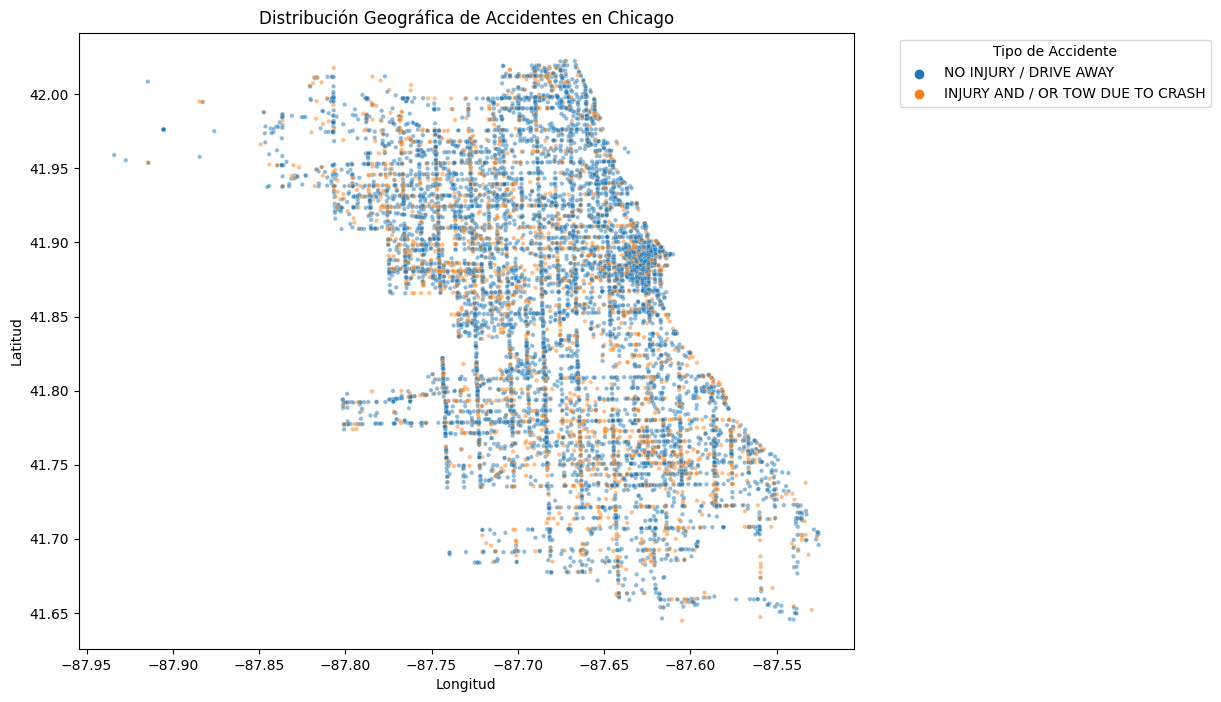

In [16]:
#Una vez hecho el preoprocesamiento, ya tenemos las variables limpias y no contamos con ningún valor faltante. 

##ANALISIS EXPLORATORIO DE DATOS
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.scatterplot(data=datos_muestra2, x='LONGITUDE', y='LATITUDE', 
                hue='CRASH_TYPE', alpha=0.5, s=10)
plt.title('Distribución Geográfica de Accidentes en Chicago')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Tipo de Accidente', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [14]:
##Análisis de la Distribución Geográfica de Accidentes
#Lo primero que destaca es que los datos "dibujan" por sí solos el mapa de Chicago. 

#Se observa un punto caliente en la zona centro-este. Esto indica que el distrito financiero y las zonas más urbanizadas presentan 
#una densidad de colisiones significativamente mayor debido al volumen de tráfico.

#Los accidentes parecen alinearse siguiendo ejes verticales y horizontales perfectos. Esto nos puede llevar a pensar que las grandes 
#avenidas y calles principales son los escenarios más comunes de siniestros, lo cual es lógico por la intensidad de ciculación.

#Los diferentes colores muestran que ciertas zonas no solo tienen más accidentes, sino que el tipo de accidente también varía según 
#la ubicación.

C:\Users\rocio\anaconda3\envs\Ampliacion_Python_R\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


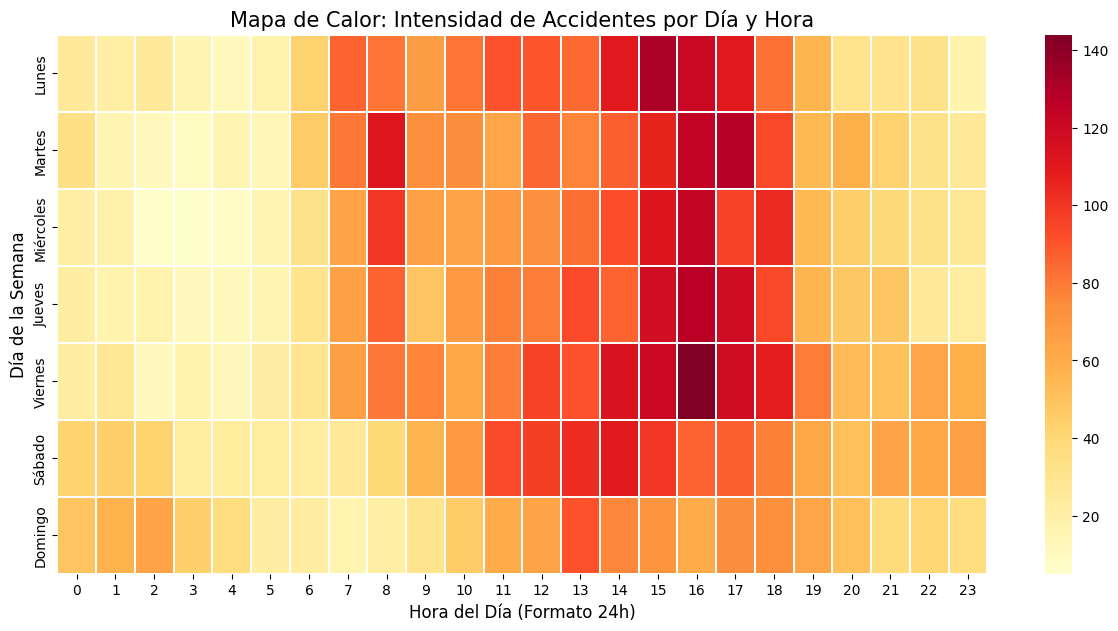

In [17]:
mapa_dias = {  1: 'Domingo',   2: 'Lunes',   3: 'Martes',   4: 'Miércoles',   5: 'Jueves',   6: 'Viernes',   7: 'Sábado'}
datos_muestra2['DAY_NAME'] = datos_muestra2['CRASH_DAY_OF_WEEK'].map(mapa_dias)
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
pivot_table = datos_muestra2.pivot_table(index='DAY_NAME', 
                                        columns='CRASH_HOUR', 
                                        values='POSTED_SPEED_LIMIT', 
                                        aggfunc='count').reindex(orden_dias)
plt.figure(figsize=(15, 7))
sns.heatmap(pivot_table, cmap='YlOrRd', annot=False, linewidths=0.1)

plt.title('Mapa de Calor: Intensidad de Accidentes por Día y Hora', fontsize=15)
plt.xlabel('Hora del Día (Formato 24h)', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)

plt.show()

In [16]:
#Análisis de la Temporalidad de Accidentes
#El "Pico de la Tarde" (La salida del trabajo):
#Destacamos una gran frecuencia de lunes a viernes, concentrándose entre las 14:00 y las 17:00 horas, estas corresponden a 
#las horas de salida del trabajo,la zona tiene un color rojo intenso, con valores cercanos a 140 incidentes.
#Esto puede ser debido a la fatiga laboral, que pueden incrementar el riesgo de accidente.

#El "Pico de la Mañana" (La entrada al trabajo):
#Se observa también una frecuencia descatable por la mañana, entre las 7:00 y 10:00 horas, aunque no tan notable como las de la tarde,
#estando también de lunes a viernes. Aunque el volumen de coches es similar, el número de accidentes es menor que en la tarde, debido a que 
#los conductores están más alerta a primera hora.

#El Viernes (El día más peligroso):
#Si observamos el Viernes, destaca como el día con la celda más oscura, a las 16:00 horas. Esto puede ser debido al cansancio 
#acumulado de la semana combinado con el inicio del fin de semana generando el momento de mayor riesgo.

#El Cambio en el Fin de Semana (Sábado y Domingo):
#El comportamiento cambia drásticamente durante el fin de semana. En los Sábados y Domingos el riesgo se distribuye de manera mucho 
#más uniforme a lo largo del día. Además, se aprecia un ligero aumento de accidentes en las primeras horas de la madrugada del 
#Domingo, lo que podría estar asociado al ocio nocturno.


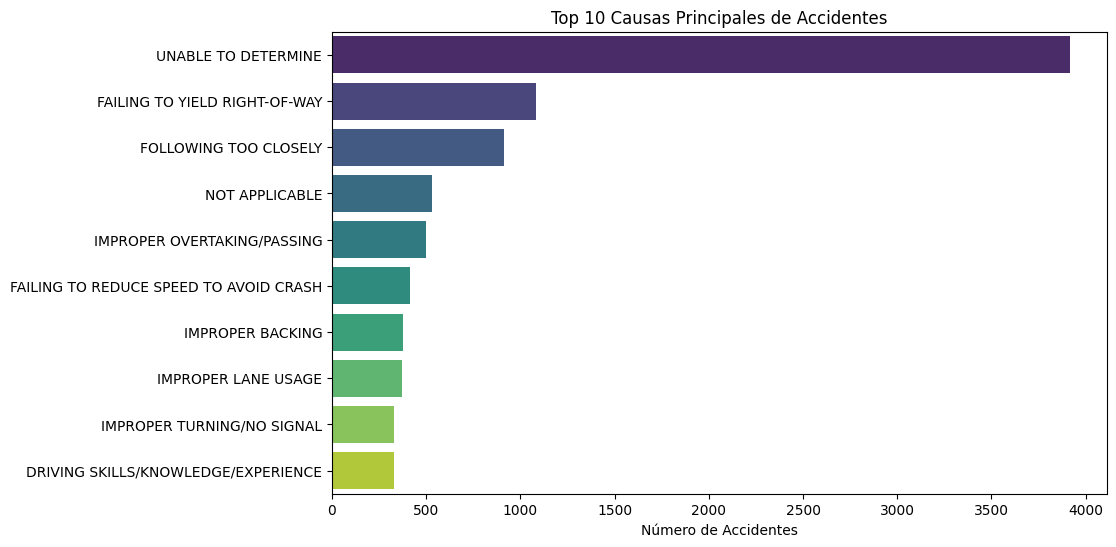

In [18]:
plt.figure(figsize=(10, 6))
top_causas = datos_muestra2['PRIM_CONTRIBUTORY_CAUSE'].value_counts().head(10)
sns.barplot(x=top_causas.values, y=top_causas.index, palette='viridis')
plt.title('Top 10 Causas Principales de Accidentes')
plt.xlabel('Número de Accidentes')
plt.show()

In [18]:
#Análisis de las Causas Principales de Accidentes
#El gráfico de barras horizontales permite identificar las situaciones que llevan a más accidentes en Chicago. 
#Los hallazgos más relevantes son:

#El predominio de la Incertidumbre, con casi 4.000 casos, siendo la causa más frecuente. Esto indica que en una gran parte de los 
#informes policiales no se encuentra evidencia para asignar una responsabilidad específica.

#Errores de Prioridad:
#Las dos causas claras más importantes son No ceder el paso y No mantener la distancia de seguridad. Esto sugiere que las colisiones 
#se suelen deber a decisiones humanas erróneas.

#Maniobras Impropias:
#Causas como adelantamiento indebido y el uso incorrecto del carril muestran que la impaciencia del conductor es un factor importante 
#en la tasa de accidentes.

#Habilidades de Conducción:
#Al final aparecen las habilidades de conducción. Aunque hay una menor frecuencia dentro de las destacadas, indica que hay un grupo 
#de accidentes ligados a la exceso de confianza del conductor.

#El análisis de las causas refuerza la idea de que la mayoría de los accidentes en Chicago son por el comportamiento de la gente. 


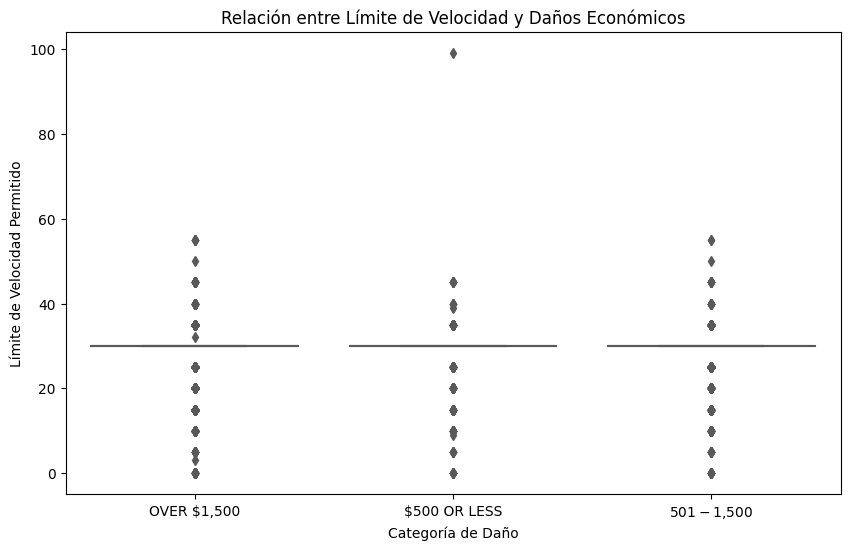

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=datos_muestra2, x='DAMAGE', y='POSTED_SPEED_LIMIT', palette='Set2')
plt.title('Relación entre Límite de Velocidad y Daños Económicos')
plt.xlabel('Categoría de Daño')
plt.ylabel('Límite de Velocidad Permitido')
plt.show()

In [20]:
#Análisis de Límite de Velocidad vs. Daños Económicos
#Este gráfico de cajas busca determinar si un límite de velocidad más alto implica daños económicos más costosos. 
#Las conclusiones son:

#Uniformidad de la Mediana: Lo más llamativo es que la mediana e mantiene idéntica en las tres categorías, situándose en las 30 m/h, 
#que equivale a unos 50km/h. Esto confirma que la mayoría de los accidentes, independientemente del costo del daño, ocurren en 
#vías urbanas estándar con un límite de 30 mph.

#Un accidente a 15 m/h contra un coche, aparentemente caro, puede elevar su coste de daño. El coste del daño está más ligado al 
#tipo de coche que a la velocidad permitida.

#Detección de Outliers:
#Vemos puntos que llegan hasta las 60 mph y un caso extremo cercano a las 100 mph en la categoría de daños menores. Este último punto 
#es muy interesante ya que indica que incluso en zonas de alta velocidad, se registran accidentes con daños mínimos.

In [20]:
import plotly.graph_objects as go

df_donut = datos_muestra2['FIRST_CRASH_TYPE'].value_counts()

fig = go.Figure(data=[go.Pie(labels=df_donut.index, values=df_donut.values, hole=.5)])

fig.update_layout(
    title_text="Proporción por Tipo de Accidente",
    annotations=[dict(text='Accidentes', x=0.5, y=0.5, font_size=20, showarrow=False)]
)

fig.show()

ModuleNotFoundError: No module named 'plotly'

In [22]:
#Análisis de la Proporción por Tipo de Accidente
#Este gráfico permite identificar cuáles son los escenarios de colisión más comunes en la ciudad:

#Los choques contra vehículos aparcados ocupan un 23.3% y los choques Traseros un 22.5% ocupan mayor parte de la gráfica. El alto índice 
#de los choques traseros son el síntoma claro de la congestión en las "horas punta" que vimos en el mapa de calor.

#Los siguientes más destacados son el Raspado Lateral en el mismo sentido, los accidentes por Giro y los choques en Ángulo. 

#Aunque algunos accidentes son mas graves, como por ejemplo, un choque frontal o un atropello, se demuestra que para la mayoría 
#de grupos identificados son eventos raros.

In [21]:
#APLICACIÓN DE TÉCNICAS DE CLUSTERING Y EVALUACIÓN DE LOS MODELOS

#K MEDIAS
#Antes de aplicar el algoritmo debemos quitar las variables objetivo, en nuestro caso son:
#MOST_SEVERE_INJURY, INJURIES_TOTAL, INJURIES_FATAL, INJURIES_INCAPACITATING, INJURIES_NON_INCAPACITATING, INJURIES_REPORTED_NOT_EVIDENT
#INJURIES_NO_INDICATION, INJURIES_UNKNOWN, CRASH_TYPE, DAMAGE, LATITUD, LONGITUDE
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

variables_consecuencia = [
    'CRASH_TYPE', 'DAMAGE',  'MOST_SEVERE_INJURY',  'INJURIES_TOTAL', 'INJURIES_FATAL', 'INJURIES_INCAPACITATING',    
    'INJURIES_NON_INCAPACITATING', 'INJURIES_REPORTED_NOT_EVIDENT',    'INJURIES_NO_INDICATION',     
    'INJURIES_UNKNOWN', 'LATITUDE', 'LONGITUDE', 'DAY_NAME']

datos_cluster = datos_muestra2.drop(columns=variables_consecuencia)

datos_objetivo = datos_muestra2[variables_consecuencia]

print("Variables para entrenar K-Medias:", datos_cluster.shape[1])
print("\nLas variables que han quedado para el clustering son:")
print(datos_cluster.columns.tolist())

Variables para entrenar K-Medias: 16

Las variables que han quedado para el clustering son:
['POSTED_SPEED_LIMIT', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'NUM_UNITS', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH']


In [22]:
#Por lo que ahora contamos con 16 variables para entrenar.

#A continuación vamos a convertir las columnas seleccionadas a dummyes.from sklearn.preprocessing import StandardScaler
import pandas as pd

# Codificamos las variables categóricas (texto) convirtiéndolas en variables dummy (0 y 1)
X_dummies = pd.get_dummies(datos_cluster, drop_first=True)

# Escalamos los datos para que variables como la velocidad o la hora no dominen a las dummies
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_dummies)

# Comprobamos las nuevas dimensiones
print(f"Dimensiones para clustering: {X_scaled.shape}")

Dimensiones para clustering: (9926, 169)


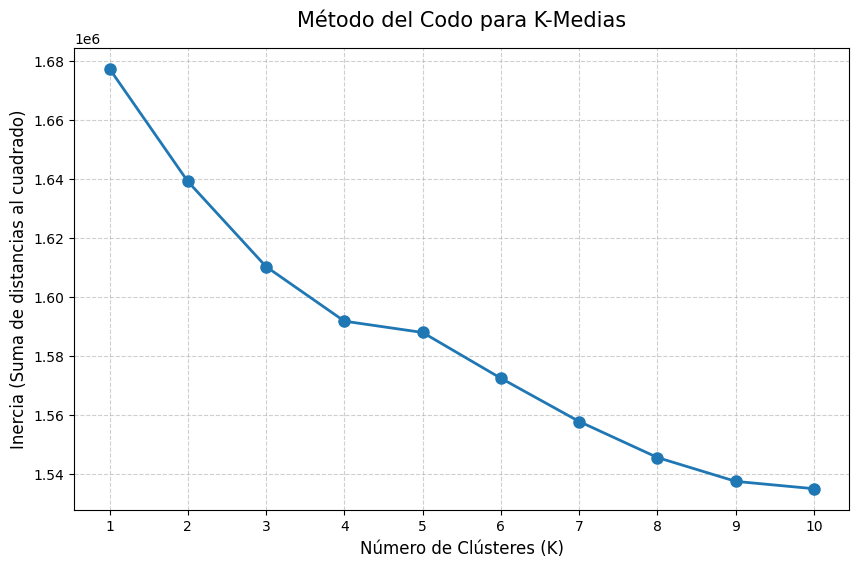

In [23]:
#Realizamos el gráfico del codo para seleccionar la K correspondiente
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inercia = []
rango_k = range(1, 11)
for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercia, marker='o', linestyle='-', color='#1f77b4', linewidth=2, markersize=8)

plt.title('Método del Codo para K-Medias', fontsize=15, pad=15)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Inercia (Suma de distancias al cuadrado)', fontsize=12)
plt.xticks(rango_k)
plt.grid(True, linestyle='--', alpha=0.6)


In [25]:
#Tras observar el gráfico del codo, decidimos probar con k=4 y k=5
#k=4, ya que podemos observar que marca el inicio del "codo"
#k=5, ya que marca el final de ese tramo de "inflexión"

# Perfil K=4
kmeans4 = KMeans(n_clusters=4, random_state=2600, n_init=10)
labels4 = kmeans4.fit_predict(X_scaled)
datos_muestra2['CLUSTER_K4'] = labels4

tamanos4 = datos_muestra2['CLUSTER_K4'].value_counts().sort_index()
porcentajes4 = (datos_muestra2['CLUSTER_K4'].value_counts(normalize=True)*100).sort_index().round(2)
print("=== DISTRIBUCIÓN K=4 ===")
for c in tamanos4.index:
    print(f"Clúster {c}: {tamanos4[c]} accidentes ({porcentajes4[c]}%)")

vars_num = ['CRASH_HOUR','CRASH_DAY_OF_WEEK','CRASH_MONTH','POSTED_SPEED_LIMIT','NUM_UNITS']
print("\n=== PERFIL NUMÉRICO MEDIO ===")
print(datos_muestra2.groupby('CLUSTER_K4')[vars_num].mean().round(2).to_string())

vars_cat = ['TRAFFIC_CONTROL_DEVICE','WEATHER_CONDITION','ROADWAY_SURFACE_COND',
            'ROAD_DEFECT','FIRST_CRASH_TYPE','PRIM_CONTRIBUTORY_CAUSE']
print("\n=== MODA POR CLÚSTER ===")
for var in vars_cat:
    print(f"\n{var}:")
    print(datos_muestra2.groupby('CLUSTER_K4')[var].agg(lambda x: x.value_counts().index[0]).to_string())

=== DISTRIBUCIÓN K=4 ===
Clúster 0: 5906 accidentes (59.5%)
Clúster 1: 3549 accidentes (35.75%)
Clúster 2: 457 accidentes (4.6%)
Clúster 3: 14 accidentes (0.14%)

=== PERFIL NUMÉRICO MEDIO ===
            CRASH_HOUR  CRASH_DAY_OF_WEEK  CRASH_MONTH  POSTED_SPEED_LIMIT  NUM_UNITS
CLUSTER_K4                                                                           
0                13.07               4.12         6.87               27.66       2.03
1                13.39               4.09         6.93               29.69       2.06
2                12.17               4.02         5.30               28.94       2.00
3                10.57               3.14         5.64               29.64       1.36

=== MODA POR CLÚSTER ===

TRAFFIC_CONTROL_DEVICE:
CLUSTER_K4
0       NO CONTROLS
1    TRAFFIC SIGNAL
2       NO CONTROLS
3       NO CONTROLS

WEATHER_CONDITION:
CLUSTER_K4
0    CLEAR
1    CLEAR
2     SNOW
3    CLEAR

ROADWAY_SURFACE_COND:
CLUSTER_K4
0              DRY
1              DRY
2 

C:\Users\rocio\anaconda3\envs\Ampliacion_Python_R\lib\site-packages\ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


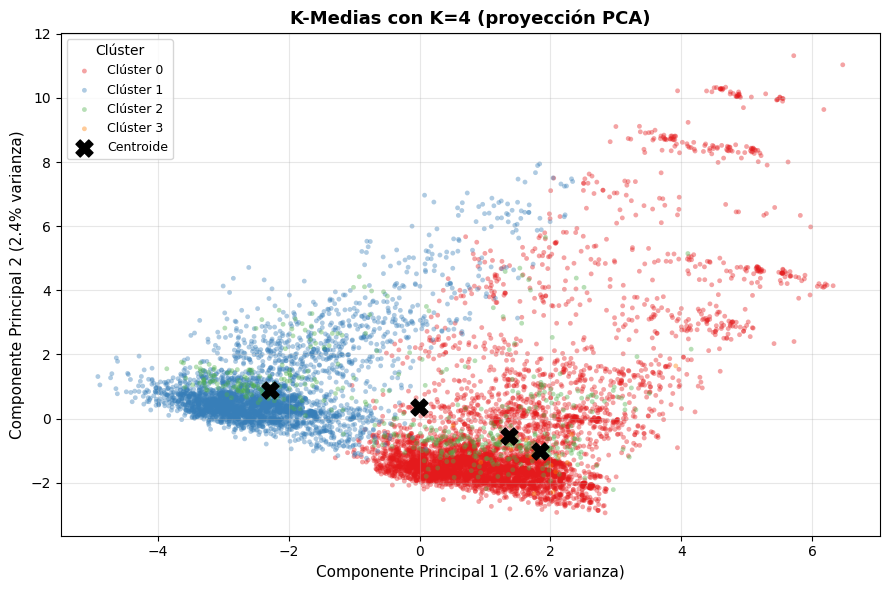

In [26]:
#Interpretación

#La partición en 4 clústeres revela:
#Clúter 0 (59.5%), es el grupo mayoritario. Agrupa accidentes que ocurren de media a las 13:00h,
#en climas despejados, vias sin señalizar, en carreteras secas, en vías sin defectos, el tipo de choque 
#principal es contra vehículos aparcados. Representa el típico golpe a baja velocidad (media de 27.66 mph) 
#en calles residenciales contra coches aparcados.

#Cluster 1 (35.75%). Agrupa accidentes que ocurren de media a las 13:30h, en climas despejados, 
# en vias señalizadas, en carreteras secas, en vías sin defectos, el tipo de choque 
#principal es la colisión (REAR END). Representa el clásico accidente de tráfico denso en 
#avenidas principales. Esto puede deberse al frenar ante los semáforos provocando choques traseros.

#Cluster 2 (4.6%). Esto grupo ya es mucho más minoritario. Agrupa accidentes que ocurren de 
#media a las 12:17h, en climas con nieve, en vias sin señalizar, en carreteras nevadas, en vías sin defectos, el tipo de choque 
#principal es la colisión (REAR END). Representa un tipo de accidente donde la causa principal es el tiempo, 
#cuando se presentan las condiciones de invierno.

#Cluster 3 (0.14%). Esto grupo es el menos común. Agrupa accidentes que ocurren de 
#media a las 11:00h, en climas despejados, en vias sin señalizar, en carreteras secas, en vías con baches o agujeros, el tipo de choque 
#principal es el impacto contra objetos fijos. Representan accidentes provocados por el mal estado
#del asfalto.

#GRÁFICO K=4
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

colores4 = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']
colores5 = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#984ea3']

pca = PCA(n_components=2, random_state=2600)
coords_2d = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

# GRÁFICO— K=4 con PCA
kmeans4 = KMeans(n_clusters=4, random_state=2600, n_init=10)
labels4 = kmeans4.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
for k in range(4):
    mask = labels4 == k
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
               c=colores4[k], label=f'Clúster {k}',
               s=12, alpha=0.4, edgecolors='none')

# Marcar centroides en el espacio PCA
centroides_pca = pca.transform(kmeans4.cluster_centers_)
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
           c='black', marker='X', s=150, zorder=5, label='Centroide')

ax.set_xlabel(f'Componente Principal 1 ({var_exp[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'Componente Principal 2 ({var_exp[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('K-Medias con K=4 (proyección PCA)', fontsize=13, fontweight='bold')
ax.legend(title='Clúster', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
#Al observar el gráfico de dispersión, se extraen las siguientes conclusiones analíticas:

#Observamos solapamientos en los clústeres
#En cuanto a los clusters 0 y 1, observamos una alta densidad y un poco de solapamiento de los datos, esto se debe a que ambos perfiles comparten 
#la mayoría de las variables a excepción de las señaliza<ciones en la vía y el tipo de impacto.

#El cluster 2 tambien se encuentra solapado debido a que comparte muchas características con los otrols cluster a excepción del clima y el estado de 
#la carretera (nevado en este caso).

#El cluster 4 representa una densidad muy pequeña.

# GRÁFICO K=5
kmeans5 = KMeans(n_clusters=5, random_state=2600, n_init=10)
labels5 = kmeans5.fit_predict(X_scaled)
datos_muestra2['CLUSTER_K5'] = labels5

tamanos5 = datos_muestra2['CLUSTER_K5'].value_counts().sort_index()
porcentajes5 = (datos_muestra2['CLUSTER_K5'].value_counts(normalize=True)*100).sort_index().round(2)
print("=== DISTRIBUCIÓN K=5 ===")
for c in tamanos5.index:
    print(f"Clúster {c}: {tamanos5[c]} accidentes ({porcentajes5[c]}%)")

vars_num = ['CRASH_HOUR','CRASH_DAY_OF_WEEK','CRASH_MONTH','POSTED_SPEED_LIMIT','NUM_UNITS']
print("\n=== PERFIL NUMÉRICO MEDIO ===")
print(datos_muestra2.groupby('CLUSTER_K5')[vars_num].mean().round(2).to_string())

vars_cat = ['TRAFFIC_CONTROL_DEVICE','WEATHER_CONDITION','ROADWAY_SURFACE_COND',
            'ROAD_DEFECT','FIRST_CRASH_TYPE','PRIM_CONTRIBUTORY_CAUSE']
for var in vars_cat:
    print(f"\n{var}:")
    print(datos_muestra2.groupby('CLUSTER_K5')[var].agg(lambda x: x.value_counts().index[0]).to_string())

=== DISTRIBUCIÓN K=5 ===
Clúster 0: 115 accidentes (1.16%)
Clúster 1: 4827 accidentes (48.63%)
Clúster 2: 730 accidentes (7.35%)
Clúster 3: 3499 accidentes (35.25%)
Clúster 4: 755 accidentes (7.61%)

=== PERFIL NUMÉRICO MEDIO ===
            CRASH_HOUR  CRASH_DAY_OF_WEEK  CRASH_MONTH  POSTED_SPEED_LIMIT  NUM_UNITS
CLUSTER_K5                                                                           
0                13.28               4.58         6.57               28.39       1.96
1                12.94               4.11         6.77               28.94       2.04
2                13.32               4.02         6.82               19.09       1.96
3                13.35               4.08         6.89               29.73       2.07
4                13.18               4.12         6.88               28.44       1.99

TRAFFIC_CONTROL_DEVICE:
CLUSTER_K5
0       NO CONTROLS
1       NO CONTROLS
2       NO CONTROLS
3    TRAFFIC SIGNAL
4           UNKNOWN

WEATHER_CONDITION:
CLUSTER_K5
0

C:\Users\rocio\anaconda3\envs\Ampliacion_Python_R\lib\site-packages\ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  from ipykernel import kernelapp as app


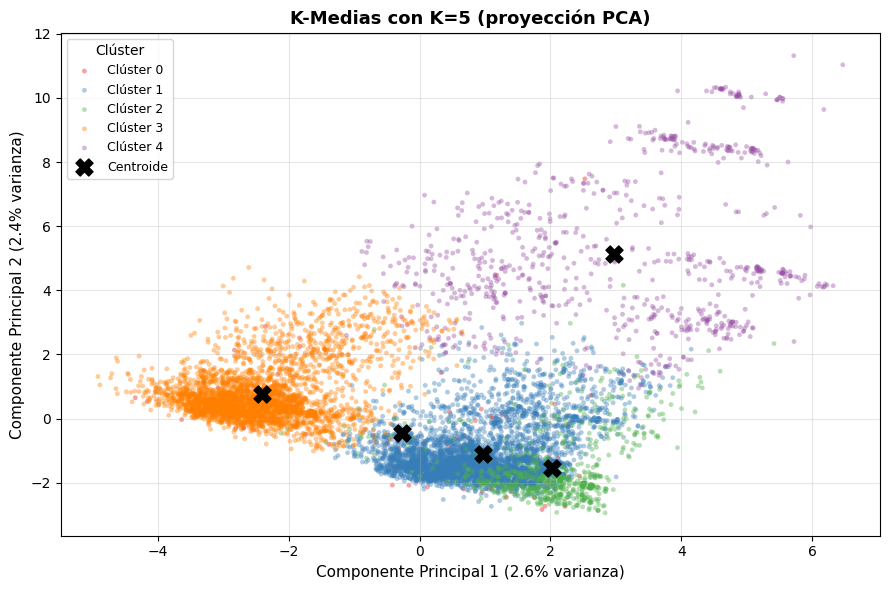

In [28]:
#Observando los resultados vemos que el perfil k=4 era mejor que este perfil k=5

#En k=5 obtenemos:

#Clúster 0 (1.16%), muy poco frecuente. Alcances en vías sin señalizar, en calles donde no hay controles de tráfico y hay buenas condiciones climáticas.

#Clúster 1 (48.63%), el más frecuente. Impactos a coches aparcados en vías sin control de tráfico, sin defectos y en buenas condiciones climáticas.

#Clúster 2 (7.35%). Impactos a coches aparcados. Es un subgrupo casi idéntico al Clúster 1, pero el algoritmo los ha separado porque ocurren en zonas 
#de velocidad reducida (la media del cluster 1 es de 28.94 mph y del cluster 2 es 19.09 mph). 

#Clúster 3 (35.25%). Colisiones por alcance en vías señalizadas, en carreteras en buenas codiciones y con buen clima.

#Clúster 4 (7.61%). Representan a coches aparcados sin testigos donde el agente de policía no pudo rellenar las condiciones del entorno.

# GRÁFICO — K=5 con PCA
kmeans5 = KMeans(n_clusters=5, random_state=2600, n_init=10)
labels5 = kmeans5.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
for k in range(5):
    mask = labels5 == k
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
               c=colores5[k], label=f'Clúster {k}',
               s=12, alpha=0.4, edgecolors='none')

centroides_pca5 = pca.transform(kmeans5.cluster_centers_)
ax.scatter(centroides_pca5[:, 0], centroides_pca5[:, 1],
           c='black', marker='X', s=150, zorder=5, label='Centroide')

ax.set_xlabel(f'Componente Principal 1 ({var_exp[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'Componente Principal 2 ({var_exp[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('K-Medias con K=5 (proyección PCA)', fontsize=13, fontweight='bold')
ax.legend(title='Clúster', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


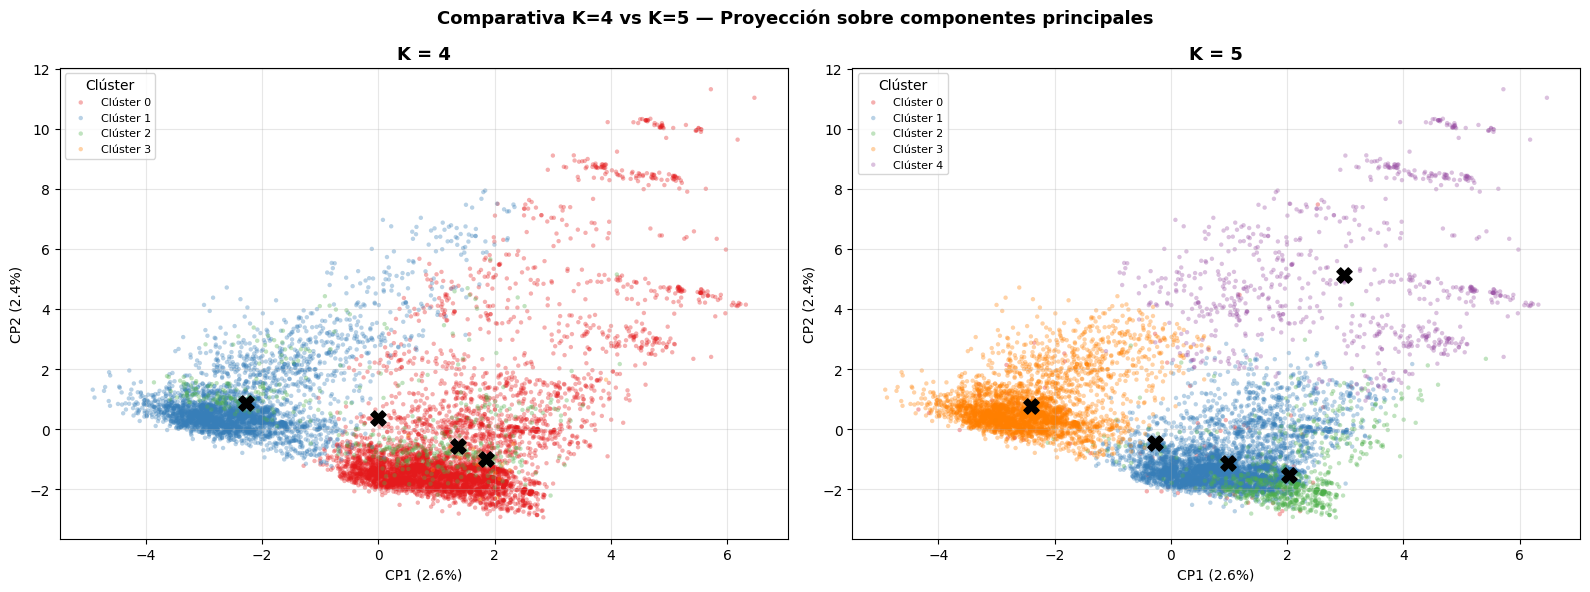

In [29]:
#Al proyectar la partición de K=5 sobre los dos primeros Componentes Principales se evidencia:

#Se observa un solapamiento entre los cluster 1 y 2. Esto se debe s lo mencionado anteriormente, ambos subgrupos son practicamente idénticos, 
#unicamente se han separado por sus velocidades medias. El cluster 3 tambien mjuestra un poco de solapamiento con estos clusteres.

#Se observa un separamiento más claro en el cluster 4, debido a sus causas desconocidas por falta de apunte de los policías.


#Comparativa K=4 vs K=5 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for k in range(4):
    mask = labels4 == k
    axes[0].scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                    c=colores4[k], label=f'Clúster {k}', s=10, alpha=0.35, edgecolors='none')
axes[0].scatter(centroides_pca[:, 0], centroides_pca[:, 1],
                c='black', marker='X', s=120, zorder=5)
axes[0].set_title('K = 4', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'CP1 ({var_exp[0]*100:.1f}%)')
axes[0].set_ylabel(f'CP2 ({var_exp[1]*100:.1f}%)')
axes[0].legend(title='Clúster', fontsize=8)
axes[0].grid(True, alpha=0.3)

for k in range(5):
    mask = labels5 == k
    axes[1].scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                    c=colores5[k], label=f'Clúster {k}', s=10, alpha=0.35, edgecolors='none')
axes[1].scatter(centroides_pca5[:, 0], centroides_pca5[:, 1],
                c='black', marker='X', s=120, zorder=5)
axes[1].set_title('K = 5', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'CP1 ({var_exp[0]*100:.1f}%)')
axes[1].set_ylabel(f'CP2 ({var_exp[1]*100:.1f}%)')
axes[1].legend(title='Clúster', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparativa K=4 vs K=5 — Proyección sobre componentes principales',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


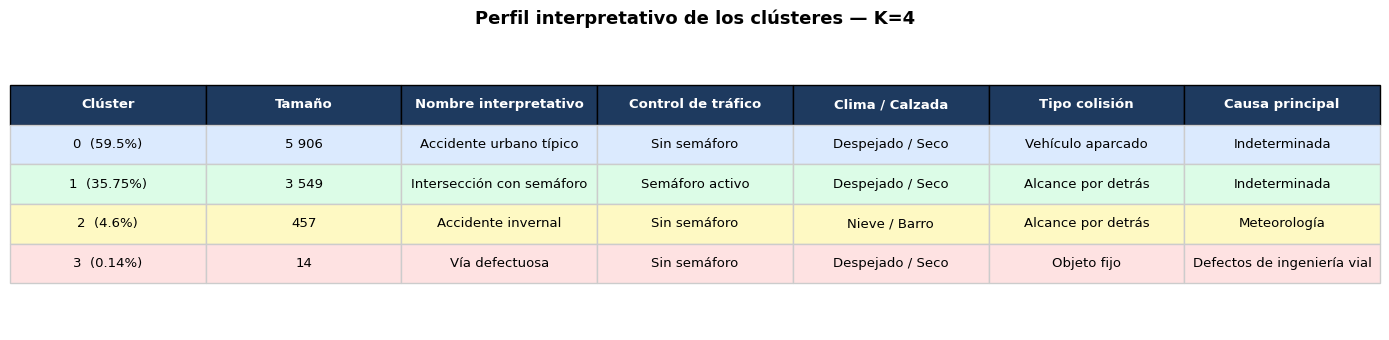

In [30]:
# TABLA RESUMEN K=4
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axis('off')

columnas = ['Clúster', 'Tamaño', 'Nombre interpretativo',
            'Control de tráfico', 'Clima / Calzada', 'Tipo colisión', 'Causa principal']

filas = [
    ['0  (59.5%)', '5 906', 'Accidente urbano típico',
     'Sin semáforo', 'Despejado / Seco', 'Vehículo aparcado', 'Indeterminada'],
    ['1  (35.75%)', '3 549', 'Intersección con semáforo',
     'Semáforo activo', 'Despejado / Seco', 'Alcance por detrás', 'Indeterminada'],
    ['2  (4.6%)', '457', 'Accidente invernal',
     'Sin semáforo', 'Nieve / Barro', 'Alcance por detrás', 'Meteorología'],
    ['3  (0.14%)', '14', 'Vía defectuosa',
     'Sin semáforo', 'Despejado / Seco', 'Objeto fijo', 'Defectos de ingeniería vial'],
]

colores_fila = ['#dbeafe', '#dcfce7', '#fef9c3', '#fee2e2'] 

tabla = ax.table(
    cellText=filas,
    colLabels=columnas,
    cellLoc='center',
    loc='center'
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(9.5)
tabla.scale(1, 2.2)

for j in range(len(columnas)):
    tabla[0, j].set_facecolor('#1e3a5f')
    tabla[0, j].set_text_props(color='white', fontweight='bold')

for i, color in enumerate(colores_fila):
    for j in range(len(columnas)):
        tabla[i + 1, j].set_facecolor(color)
        tabla[i + 1, j].set_edgecolor('#cccccc')

plt.title('Perfil interpretativo de los clústeres — K=4',
          fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

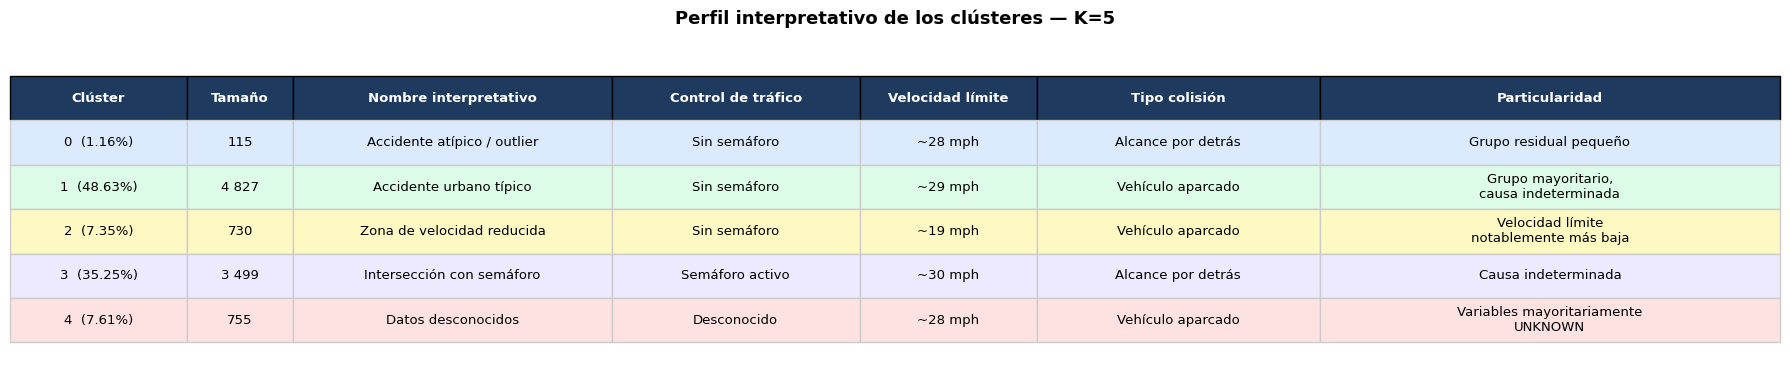

In [31]:
# TABLA RESUMEN K=5
fig, ax = plt.subplots(figsize=(18, 4))
ax.axis('off')
columnas = ['Clúster', 'Tamaño', 'Nombre interpretativo',
            'Control de tráfico', 'Velocidad límite', 'Tipo colisión', 'Particularidad']
filas = [
    ['0  (1.16%)',  '115',   'Accidente atípico / outlier',
     'Sin semáforo', '~28 mph', 'Alcance por detrás', 'Grupo residual pequeño'],
    ['1  (48.63%)', '4 827', 'Accidente urbano típico',
     'Sin semáforo', '~29 mph', 'Vehículo aparcado',  'Grupo mayoritario,\ncausa indeterminada'],
    ['2  (7.35%)',  '730',   'Zona de velocidad reducida',
     'Sin semáforo', '~19 mph', 'Vehículo aparcado',  'Velocidad límite\nnotablemente más baja'],
    ['3  (35.25%)', '3 499', 'Intersección con semáforo',
     'Semáforo activo', '~30 mph', 'Alcance por detrás', 'Causa indeterminada'],
    ['4  (7.61%)',  '755',   'Datos desconocidos',
     'Desconocido',  '~28 mph', 'Vehículo aparcado',  'Variables mayoritariamente\nUNKNOWN'],
]

col_widths = [0.10, 0.06, 0.18, 0.14, 0.10, 0.16, 0.26]

colores_fila = ['#dbeafe', '#dcfce7', '#fef9c3', '#ede9fe', '#fee2e2']
tabla = ax.table(
    cellText=filas,
    colLabels=columnas,
    cellLoc='center',
    loc='center',
    colWidths=col_widths
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9.5)
tabla.scale(1, 2.4)
for j in range(len(columnas)):
    tabla[0, j].set_facecolor('#1e3a5f')
    tabla[0, j].set_text_props(color='white', fontweight='bold')
for i, color in enumerate(colores_fila):
    for j in range(len(columnas)):
        tabla[i + 1, j].set_facecolor(color)
        tabla[i + 1, j].set_edgecolor('#cccccc')
plt.title('Perfil interpretativo de los clústeres — K=5',
          fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

Datos para Gower: (9926, 18)
Muestra para Gower: (9926, 18)


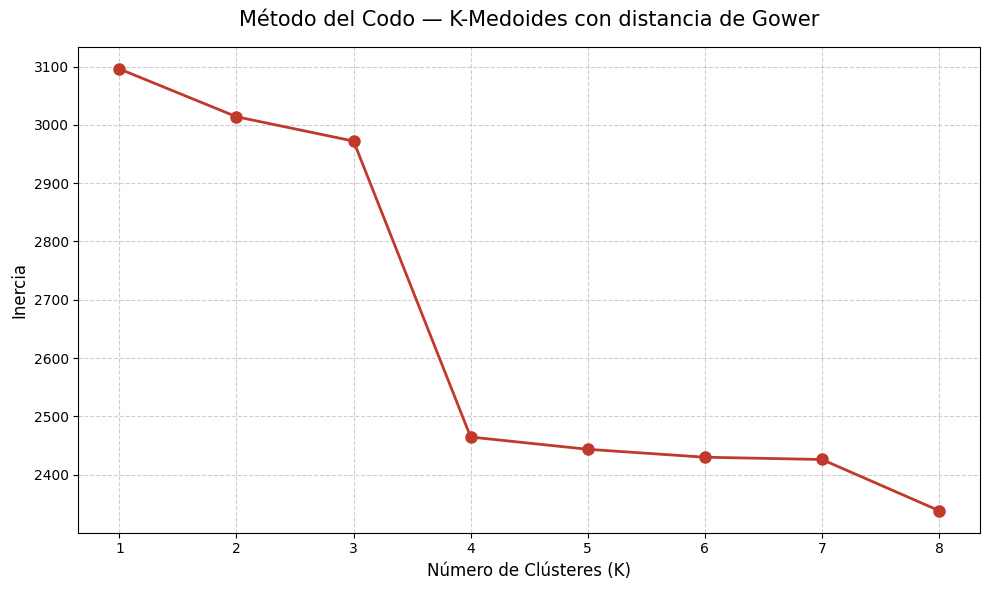

In [40]:
#K MEDOIDES
import gower
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn_extra.cluster import KMedoids
from sklearn.decomposition import PCA

variables_consecuencia = [
    'CRASH_TYPE', 'DAMAGE', 'MOST_SEVERE_INJURY', 'INJURIES_TOTAL', 'INJURIES_FATAL',
    'INJURIES_INCAPACITATING', 'INJURIES_NON_INCAPACITATING', 'INJURIES_REPORTED_NOT_EVIDENT',
    'INJURIES_NO_INDICATION', 'INJURIES_UNKNOWN', 'LATITUDE', 'LONGITUDE', 'DAY_NAME'
]

datos_gower = datos_muestra2.drop(columns=variables_consecuencia)

cols_numericas  = ['POSTED_SPEED_LIMIT', 'NUM_UNITS', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH']
cols_categoricas = ['TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION',
                    'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE',
                    'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT',
                    'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE']

for col in cols_categoricas:
    datos_gower[col] = datos_gower[col].astype(str)
for col in cols_numericas:
    datos_gower[col] = pd.to_numeric(datos_gower[col], errors='coerce')

datos_gower = datos_gower.dropna()
print(f"Datos para Gower: {datos_gower.shape}")

np.random.seed(2600)
n_muestra = 9926  
idx = np.random.choice(len(datos_gower), size=n_muestra, replace=False)
datos_gower_muestra = datos_gower.iloc[idx].reset_index(drop=True)

print(f"Muestra para Gower: {datos_gower_muestra.shape}")

dist_gower = gower.gower_matrix(datos_gower_muestra)

inercia_gower = []
rango_k = range(1, 9)

for k in rango_k:
    km = KMedoids(n_clusters=k, metric='precomputed', random_state=42, max_iter=300)
    km.fit(dist_gower)
    inercia_gower.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercia_gower, marker='o', linestyle='-',
         color='#c0392b', linewidth=2, markersize=8)
plt.title('Método del Codo — K-Medoides con distancia de Gower', fontsize=15, pad=15)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Inercia', fontsize=12)
plt.xticks(rango_k)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [47]:
#Observamos claramente que el codo se encuentra en K=4

#  MODELO FINAL K=4 
kmed4 = KMedoids(n_clusters=4, metric='precomputed', random_state=2600, max_iter=300)
kmed4.fit(dist_gower)
labels_gower4 = kmed4.labels_
datos_gower_muestra['CLUSTER_KMED4'] = labels_gower4

tamanos4 = pd.Series(labels_gower4).value_counts().sort_index()
pct4     = (pd.Series(labels_gower4).value_counts(normalize=True)*100).sort_index().round(2)
print("\n=== DISTRIBUCIÓN K-MEDOIDES K=4 ===")
for c in tamanos4.index:
    print(f"  Clúster {c}: {tamanos4[c]} accidentes ({pct4[c]}%)")


=== DISTRIBUCIÓN K-MEDOIDES K=4 ===
  Clúster 0: 1945 accidentes (19.6%)
  Clúster 1: 1952 accidentes (19.67%)
  Clúster 2: 2220 accidentes (22.37%)
  Clúster 3: 3809 accidentes (38.37%)


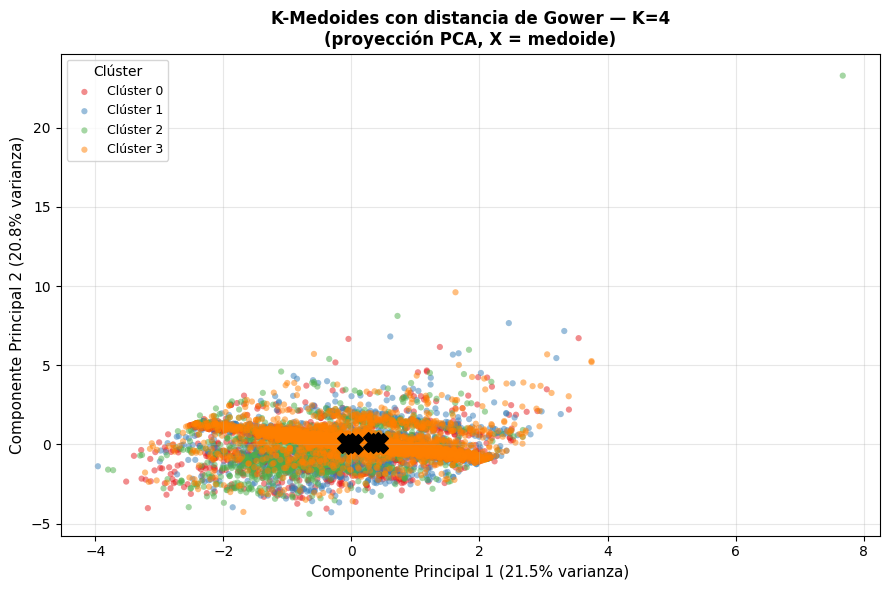

In [48]:
#K-Medoides con la métrica de Gower revela una estructura mucho más equilibrada que k medias, los resutados que obtenemos con k medoides son:

#Clúster 0: 19.60%
#Clúster 1: 19.67%
#Clúster 2: 22.37%
#Clúster 3: 38.37%


X_num_scaled = StandardScaler().fit_transform(datos_gower_muestra[cols_numericas])
pca_vis  = PCA(n_components=2, random_state=2600)
coords   = pca_vis.fit_transform(X_num_scaled)
var_exp  = pca_vis.explained_variance_ratio_

colores4 = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']

fig, ax = plt.subplots(figsize=(9, 6))
for k in range(4):
    mask = labels_gower4 == k
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=colores4[k], label=f'Clúster {k}', s=20, alpha=0.5, edgecolors='none')

for k, idx_med in enumerate(kmed4.medoid_indices_):
    ax.scatter(coords[idx_med, 0], coords[idx_med, 1],
               c='black', marker='X', s=200, zorder=5)

ax.set_xlabel(f'Componente Principal 1 ({var_exp[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'Componente Principal 2 ({var_exp[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('K-Medoides con distancia de Gower — K=4\n(proyección PCA, X = medoide)',
             fontsize=12, fontweight='bold')
ax.legend(title='Clúster', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [49]:
#Al proyectar K-Medoides sobre los dos primeros Componentes Principales obtenemos:

# Una disposición en bandas diagonales paralelas. Sin embargo, detectamos que el solapamiento entre los clústeres sigue siendo enorme. 
#Este solapamiento se debe a que estamos comprimiendo un espacio de múltiples dimensiones en solo dos. Puntos que parecen pisarse en 2D 
#podrían estar muy separados si pudiéramos ver el gráfico en otra dimensión, por ejemplo, 3D o 4D. Tambien esto es debikdol a que los accidentes
#comparten múltiples características.

perfil_kmed4 = datos_gower_muestra.groupby('CLUSTER_KMED4')[cols_numericas].mean()
print("\n=== PERFIL NUMÉRICO MEDIO ===")
print(perfil_kmed4.round(2).to_string())

print("\n=== MODA CATEGÓRICA ===")
for var in cols_categoricas:
    print(f"\n{var}:")
    print(datos_gower_muestra.groupby('CLUSTER_KMED4')[var].agg(
        lambda x: x.value_counts().index[0]).to_string())


=== PERFIL NUMÉRICO MEDIO ===
               POSTED_SPEED_LIMIT  NUM_UNITS  CRASH_HOUR  CRASH_DAY_OF_WEEK  CRASH_MONTH
CLUSTER_KMED4                                                                           
0                           27.77       2.03       11.39               4.85         3.39
1                           27.74       2.03       12.15               5.01        10.13
2                           27.48       2.03       15.16               2.62         6.74
3                           29.73       2.06       13.35               4.11         6.92

=== MODA CATEGÓRICA ===

TRAFFIC_CONTROL_DEVICE:
CLUSTER_KMED4
0       NO CONTROLS
1       NO CONTROLS
2       NO CONTROLS
3    TRAFFIC SIGNAL

DEVICE_CONDITION:
CLUSTER_KMED4
0             NO CONTROLS
1             NO CONTROLS
2             NO CONTROLS
3    FUNCTIONING PROPERLY

WEATHER_CONDITION:
CLUSTER_KMED4
0    CLEAR
1    CLEAR
2    CLEAR
3    CLEAR

LIGHTING_CONDITION:
CLUSTER_KMED4
0    DAYLIGHT
1    DAYLIGHT
2    DAYLIGHT

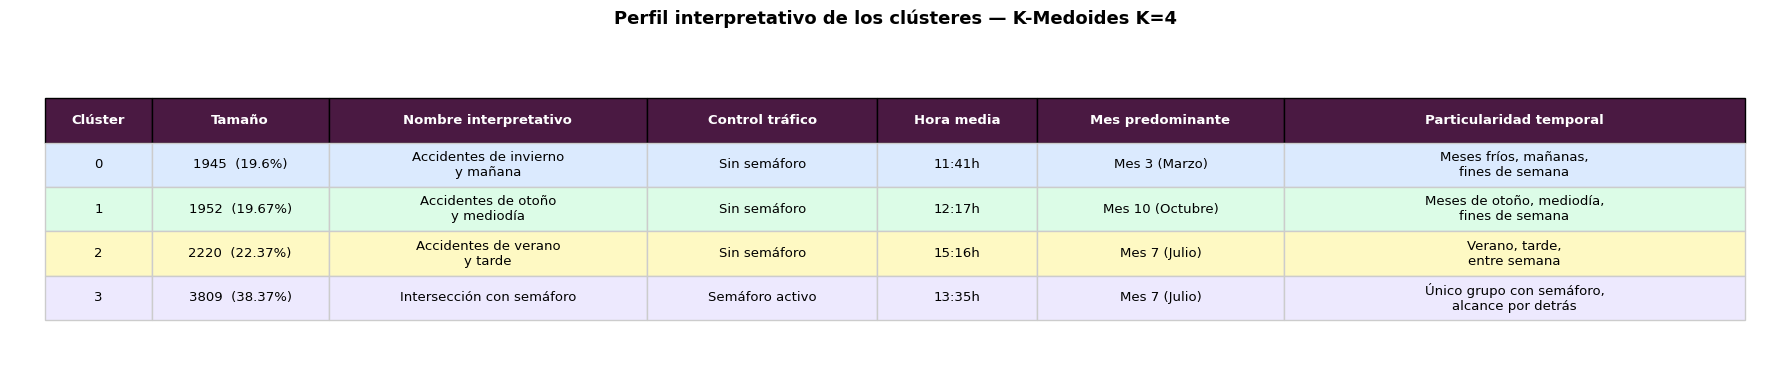

In [50]:
#Ahora cobra sentido lo que observamos al represengtar el PCA. De los 4 grupos, tres de ellos (0, 1 y 2) tienen exactamente la misma categoría en todas
#las variables. Todos son impactos contra coches aparcados, en vías de doble sentido sin separación, sin señalizaciones, de día y con buen clima. Su 
#separación en 3 cluster se debe a las variables Hora, Día y Mes.

#Es el único grupo que presenta una diferencia con respecto a los otros. Agrupa colisiones por alcance que ocurren en vias señalizadas. Representa el 
#típico accidente de tráfico por frenadas en vías principales.


# TABLA RESUMEN  K=4
fig, ax = plt.subplots(figsize=(18, 4))
ax.axis('off')
columnas = ['Clúster', 'Tamaño', 'Nombre interpretativo',
            'Control tráfico', 'Hora media', 'Mes predominante', 'Particularidad temporal']
filas = [
    ['0', f"{tamanos4[0]}  ({pct4[0]}%)", 'Accidentes de invierno\ny mañana',
     'Sin semáforo', '11:41h', 'Mes 3 (Marzo)', 'Meses fríos, mañanas,\nfines de semana'],
    ['1', f"{tamanos4[1]}  ({pct4[1]}%)", 'Accidentes de otoño\ny mediodía',
     'Sin semáforo', '12:17h', 'Mes 10 (Octubre)', 'Meses de otoño, mediodía,\nfines de semana'],
    ['2', f"{tamanos4[2]}  ({pct4[2]}%)", 'Accidentes de verano\ny tarde',
     'Sin semáforo', '15:16h', 'Mes 7 (Julio)', 'Verano, tarde,\nentre semana'],
    ['3', f"{tamanos4[3]}  ({pct4[3]}%)", 'Intersección con semáforo',
     'Semáforo activo', '13:35h', 'Mes 7 (Julio)', 'Único grupo con semáforo,\nalcance por detrás'],
]
col_widths = [0.06, 0.10, 0.18, 0.13, 0.09, 0.14, 0.26]

colores_fila = ['#dbeafe', '#dcfce7', '#fef9c3', '#ede9fe']
tabla = ax.table(
    cellText=filas,
    colLabels=columnas,
    cellLoc='center',
    loc='center',
    colWidths=col_widths
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9.5)
tabla.scale(1, 2.4)

for j in range(len(columnas)):
    tabla[0, j].set_facecolor('#4a1942')
    tabla[0, j].set_text_props(color='white', fontweight='bold')
for i, color in enumerate(colores_fila):
    for j in range(len(columnas)):
        tabla[i + 1, j].set_facecolor(color)
        tabla[i + 1, j].set_edgecolor('#cccccc')
plt.title('Perfil interpretativo de los clústeres — K-Medoides K=4',
          fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

Datos: (9926, 18)
Muestra: (1500, 18)


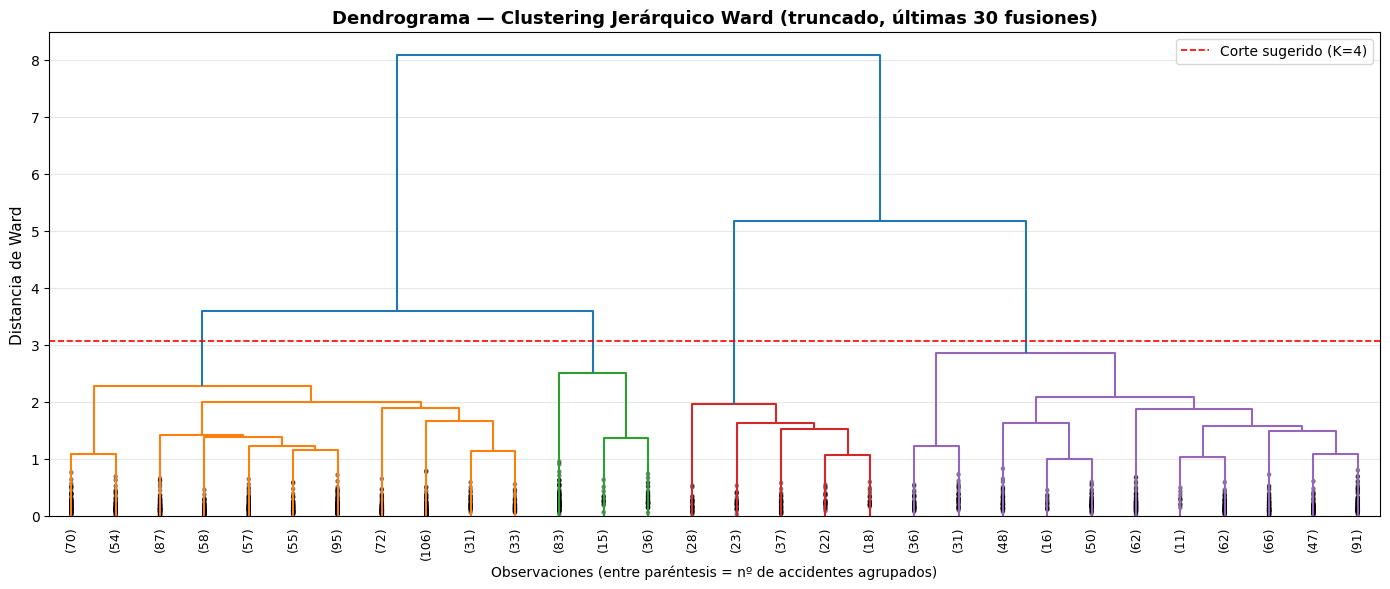

In [51]:
#METODO CLUSTERING JERARQUICO, METODO AGLOMERATIVO DE WARD

import gower
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

variables_consecuencia = [
    'CRASH_TYPE', 'DAMAGE', 'MOST_SEVERE_INJURY', 'INJURIES_TOTAL', 'INJURIES_FATAL',
    'INJURIES_INCAPACITATING', 'INJURIES_NON_INCAPACITATING', 'INJURIES_REPORTED_NOT_EVIDENT',
    'INJURIES_NO_INDICATION', 'INJURIES_UNKNOWN', 'LATITUDE', 'LONGITUDE', 'DAY_NAME'
]

cols_numericas   = ['POSTED_SPEED_LIMIT', 'NUM_UNITS', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH']
cols_categoricas = ['TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION',
                    'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE',
                    'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT',
                    'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE']

datos_ward = datos_muestra2.drop(columns=variables_consecuencia)
for col in cols_categoricas:
    datos_ward[col] = datos_ward[col].astype(str)
for col in cols_numericas:
    datos_ward[col] = pd.to_numeric(datos_ward[col], errors='coerce')
datos_ward = datos_ward.dropna()
print(f"Datos: {datos_ward.shape}")

np.random.seed(2600)
idx_ward = np.random.choice(len(datos_ward), size=1500, replace=False)
datos_ward_muestra = datos_ward.iloc[idx_ward].reset_index(drop=True)
print(f"Muestra: {datos_ward_muestra.shape}")

dist_gower_ward = gower.gower_matrix(datos_ward_muestra)
dist_condensada = squareform(dist_gower_ward, checks=False)
Z = linkage(dist_condensada, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='lastp',  
    p=30,                 
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    ax=ax,
    color_threshold=0.38 * max(Z[:, 2])
)
ax.set_title('Dendrograma — Clustering Jerárquico Ward (truncado, últimas 30 fusiones)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Observaciones (entre paréntesis = nº de accidentes agrupados)', fontsize=10)
ax.set_ylabel('Distancia de Ward', fontsize=11)
ax.axhline(y=0.38 * max(Z[:, 2]), color='red', linestyle='--',
           linewidth=1.2, label='Corte sugerido (K=4)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [53]:
#El Clustering Jerárquico construye un árbol, se demuestra visualmente que K=4 es la decisión correcta.

#DISTRIBUCIÓN WARD K=4
labels_ward = fcluster(Z, t=4, criterion='maxclust') - 1  
datos_ward_muestra['CLUSTER_WARD'] = labels_ward

tamanos_w = pd.Series(labels_ward).value_counts().sort_index()
pct_w     = (pd.Series(labels_ward).value_counts(normalize=True)*100).sort_index().round(2)
print("\n=== DISTRIBUCIÓN WARD K=4 ===")
for c in tamanos_w.index:
    print(f"  Clúster {c}: {tamanos_w[c]} accidentes ({pct_w[c]}%)")
perfil_ward      = datos_ward_muestra.groupby('CLUSTER_WARD')[cols_numericas].mean()

print("\n=== PERFIL NUMÉRICO MEDIO ===")
print(perfil_ward.round(2).to_string())

print("\n=== MODA CATEGÓRICA ===")
for var in cols_categoricas:
    print(f"\n{var}:")
    print(datos_ward_muestra.groupby('CLUSTER_WARD')[var].agg(
        lambda x: x.value_counts().index[0]).to_string())


=== DISTRIBUCIÓN WARD K=4 ===
  Clúster 0: 718 accidentes (47.87%)
  Clúster 1: 134 accidentes (8.93%)
  Clúster 2: 128 accidentes (8.53%)
  Clúster 3: 520 accidentes (34.67%)

=== PERFIL NUMÉRICO MEDIO ===
              POSTED_SPEED_LIMIT  NUM_UNITS  CRASH_HOUR  CRASH_DAY_OF_WEEK  CRASH_MONTH
CLUSTER_WARD                                                                           
0                          27.58       2.05       13.28               4.15         6.96
1                          28.69       2.02       12.02               3.87         5.75
2                          28.44       2.00       13.59               3.98         6.77
3                          29.61       2.08       13.30               4.13         7.16

=== MODA CATEGÓRICA ===

TRAFFIC_CONTROL_DEVICE:
CLUSTER_WARD
0       NO CONTROLS
1       NO CONTROLS
2           UNKNOWN
3    TRAFFIC SIGNAL

DEVICE_CONDITION:
CLUSTER_WARD
0             NO CONTROLS
1             NO CONTROLS
2                 UNKNOWN
3    FUNCTI

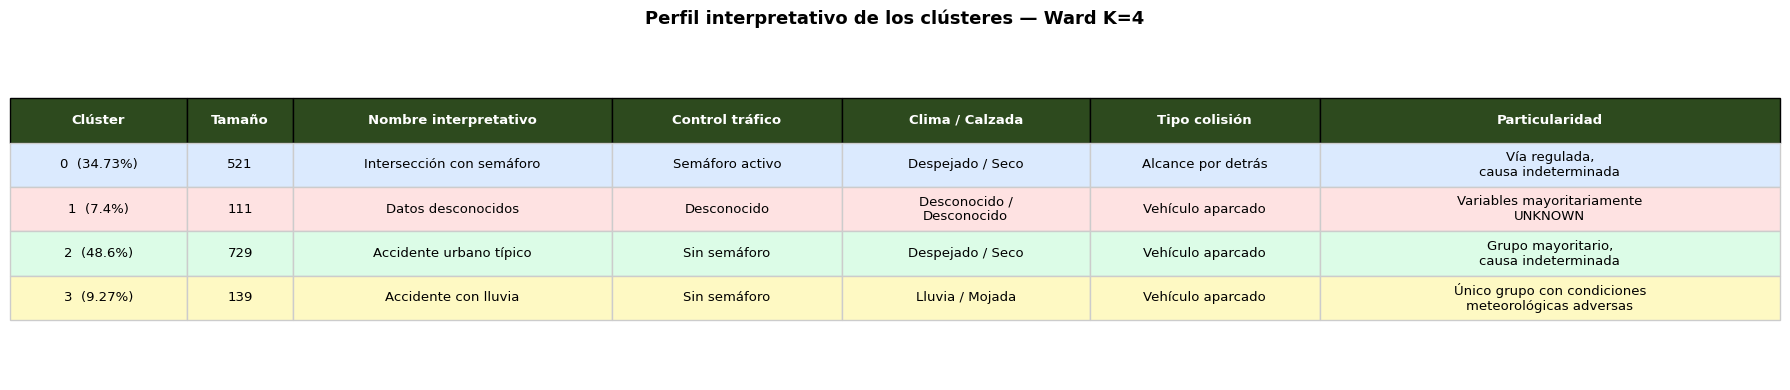

In [54]:
#Los 4 clústeres identificados son:

#Clúster 0 (34.73%). Se caracteriza por colisiones por alcance en cruces señalizados que funcionaban correctamente, con buenas condiciones temporales.

#Clúster 1 (7.40%). Se caracteriza por la deficiencia en el registro policial. Se ha detectado un clúster donde la moda para casi todas las 
#variables es desconocido.

#Clúster 2 (48.60%). Es el grupo mayoritario. Agrupa las colisiones contra coches aparcados en calles de doble sentido sin separación, sin señalizar
#y en condiciones climáticas óptimas.

#Clúster 3 (9.27%). La característica diferencial de este grupo es el clima lluvioso y el asfalto mojado. Afecta principalmente a vehículos aparcados 
#en vías sin señalizar.


# TABLA RESUMEN K=4
fig, ax = plt.subplots(figsize=(18, 4))
ax.axis('off')
columnas = ['Clúster', 'Tamaño', 'Nombre interpretativo',
            'Control tráfico', 'Clima / Calzada', 'Tipo colisión', 'Particularidad']
filas = [
    ['0  (34.73%)', '521', 'Intersección con semáforo',
     'Semáforo activo', 'Despejado / Seco', 'Alcance por detrás',
     'Vía regulada,\ncausa indeterminada'],
    ['1  (7.4%)',   '111', 'Datos desconocidos',
     'Desconocido',    'Desconocido /\nDesconocido', 'Vehículo aparcado',
     'Variables mayoritariamente\nUNKNOWN'],
    ['2  (48.6%)',  '729', 'Accidente urbano típico',
     'Sin semáforo',   'Despejado / Seco', 'Vehículo aparcado',
     'Grupo mayoritario,\ncausa indeterminada'],
    ['3  (9.27%)',  '139', 'Accidente con lluvia',
     'Sin semáforo',   'Lluvia / Mojada', 'Vehículo aparcado',
     'Único grupo con condiciones\nmeteorológicas adversas'],
]
col_widths = [0.10, 0.06, 0.18, 0.13, 0.14, 0.13, 0.26]

colores_fila = ['#dbeafe', '#fee2e2', '#dcfce7', '#fef9c3']
tabla = ax.table(
    cellText=filas,
    colLabels=columnas,
    cellLoc='center',
    loc='center',
    colWidths=col_widths
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9.5)
tabla.scale(1, 2.4)

for j in range(len(columnas)):
    tabla[0, j].set_facecolor('#2d4a1e')
    tabla[0, j].set_text_props(color='white', fontweight='bold')
for i, color in enumerate(colores_fila):
    for j in range(len(columnas)):
        tabla[i + 1, j].set_facecolor(color)
        tabla[i + 1, j].set_edgecolor('#cccccc')
plt.title('Perfil interpretativo de los clústeres — Ward K=4',
          fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

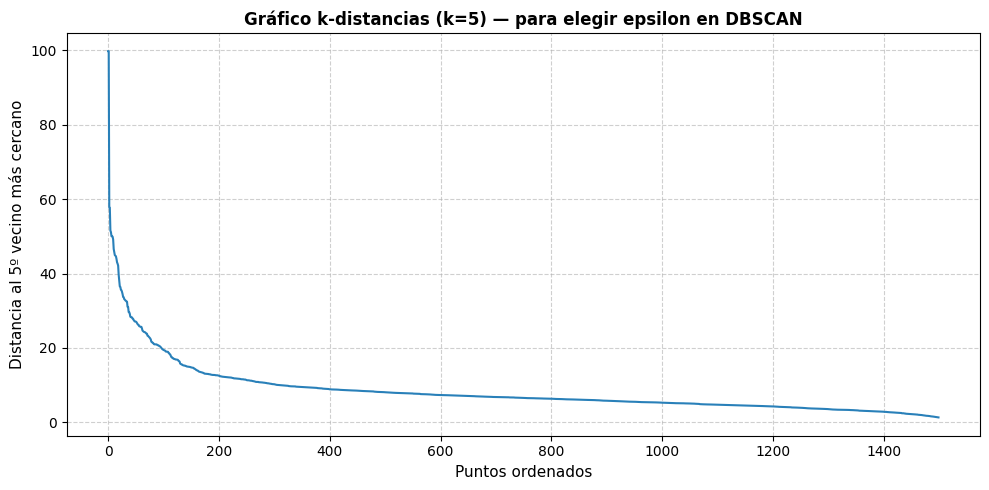


Percentiles de distancia (orientativo para epsilon):
  Percentil 90: 3.2734
  Percentil 95: 2.6152
  Percentil 97: 2.1919
  Percentil 99: 1.6884


In [55]:
#DBSCAN
import numpy as np
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5, metric='euclidean').fit(X_scaled[idx_ward])
distancias_knn, _ = nbrs.kneighbors(X_scaled[idx_ward])
distancias_5 = np.sort(distancias_knn[:, 4])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(distancias_5, color='#2980b9', linewidth=1.5)
plt.title('Gráfico k-distancias (k=5) — para elegir epsilon en DBSCAN',
          fontsize=12, fontweight='bold')
plt.xlabel('Puntos ordenados', fontsize=11)
plt.ylabel('Distancia al 5º vecino más cercano', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nPercentiles de distancia (orientativo para epsilon):")
for p in [90, 95, 97, 99]:
    print(f"  Percentil {p}: {np.percentile(distancias_5, 100-p):.4f}")

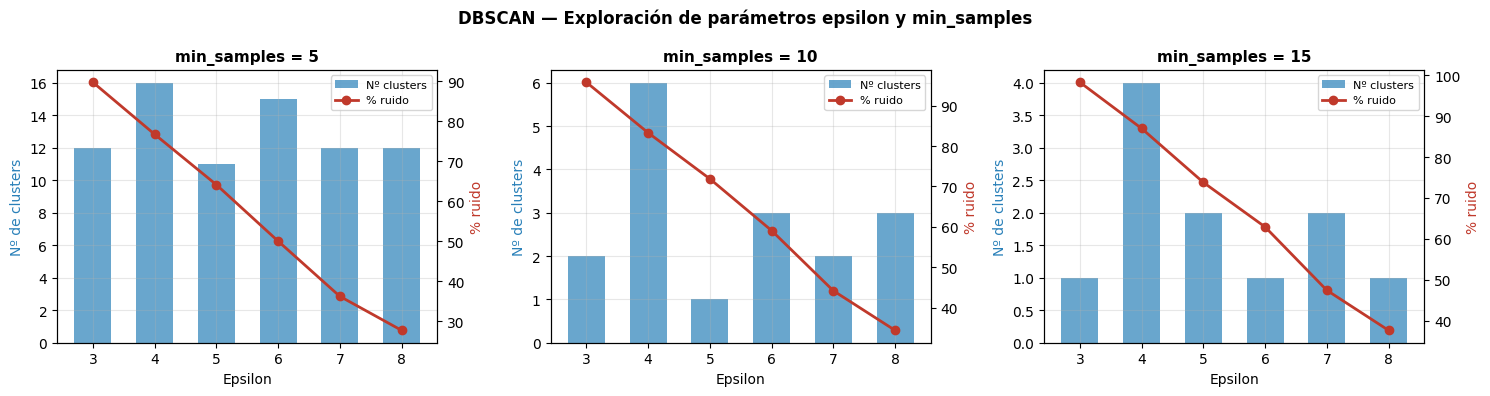

In [56]:
#En cuanto a la elección del parámetro epsilon. Si elegimos un valor muy bajo, el modelo será demasiado estricto y clasificará casi todos los 
#accidentes como anomalías. Si elegimos un valor muy alto, el modelo mezclará todos los accidentes en un único grupo sin distinguir patrones. El epsilon
#óptimo se encuentra en el valor 2.37 (correspondiente al percentil 95), de esta manera el algoritmo agrupará la siniestralidad con una exigencia
#razonable, aislando únicamente como anomalías al 5% de los accidentes que representan situaciones extremadamente raras.


from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_dbscan = X_scaled[idx_ward]

epsilons         = [3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
min_samples_list = [5, 10, 15]

resultados = []
for eps in epsilons:
    for ms in min_samples_list:
        db     = DBSCAN(eps=eps, min_samples=ms, metric='euclidean', n_jobs=-1)
        labels = db.fit_predict(X_dbscan)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruido    = (labels == -1).sum()
        pct_ruido  = round(n_ruido / len(labels) * 100, 1)
        sil = None
        if n_clusters >= 2:
            try:
                sil = round(silhouette_score(X_dbscan, labels,
                                              sample_size=500, random_state=2600), 4)
            except:
                sil = None
        resultados.append({'epsilon': eps, 'min_samples': ms,
                            'n_clusters': n_clusters, 'pct_ruido': pct_ruido,
                            'silhouette': sil})

df_res = pd.DataFrame(resultados)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ms in zip(axes, min_samples_list):
    sub = df_res[df_res['min_samples'] == ms]
    ax2 = ax.twinx()
    ax.bar(sub['epsilon'], sub['n_clusters'], width=0.6,
           color='#2980b9', alpha=0.7, label='Nº clusters')
    ax2.plot(sub['epsilon'], sub['pct_ruido'], marker='o',
             color='#c0392b', linewidth=2, label='% ruido')
    ax.set_title(f'min_samples = {ms}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Epsilon', fontsize=10)
    ax.set_ylabel('Nº de clusters', color='#2980b9', fontsize=10)
    ax2.set_ylabel('% ruido', color='#c0392b', fontsize=10)
    ax.set_xticks(epsilons)
    ax.grid(True, alpha=0.3)
    lines1, lab1 = ax.get_legend_handles_labels()
    lines2, lab2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lab1 + lab2, fontsize=8)

plt.suptitle('DBSCAN — Exploración de parámetros epsilon y min_samples',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
#CONCLUSIÓN — DBSCAN no es adecuado para este dataset.
#En todas las combinaciones probadas:
  #- El porcentaje de ruido oscila entre el 24% y el 97%.
  #- El índice Silhouette es negativo o cercado a 0 en todos los casos.
  #- El clúster mayoritario acapara casi todos los puntos válidos, mientras el resto son microgrupos de 5-16 accidentes.

#Esto indica que los accidentes no forman zonas de densidad diferenciada en el espacio de variables. DBSCAN requiere esa estructura para funcionar, 
#por lo que se descarta este método y se continúa el análisis con K-Medias y Ward.

In [61]:
#K FUZZY

import skfuzzy as fuzz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_fuzzy = PCA(n_components=0.80, random_state=2600)
X_pca_fuzzy = pca_fuzzy.fit_transform(X_scaled)
print(f"Dimensiones originales : {X_scaled.shape}")
print(f"Dimensiones tras PCA   : {X_pca_fuzzy.shape}")
print(f"Varianza explicada     : {pca_fuzzy.explained_variance_ratio_.sum()*100:.1f}%")

idx_fuzzy = np.random.choice(len(X_pca_fuzzy), size=9926, replace=False)
X_fuzzy   = X_pca_fuzzy[idx_fuzzy].T 
print(f"\nMuestra para Fuzzy C-Means: {X_fuzzy.T.shape}")

Dimensiones originales : (9926, 169)
Dimensiones tras PCA   : (9926, 110)
Varianza explicada     : 80.1%

Muestra para Fuzzy C-Means: (9926, 110)


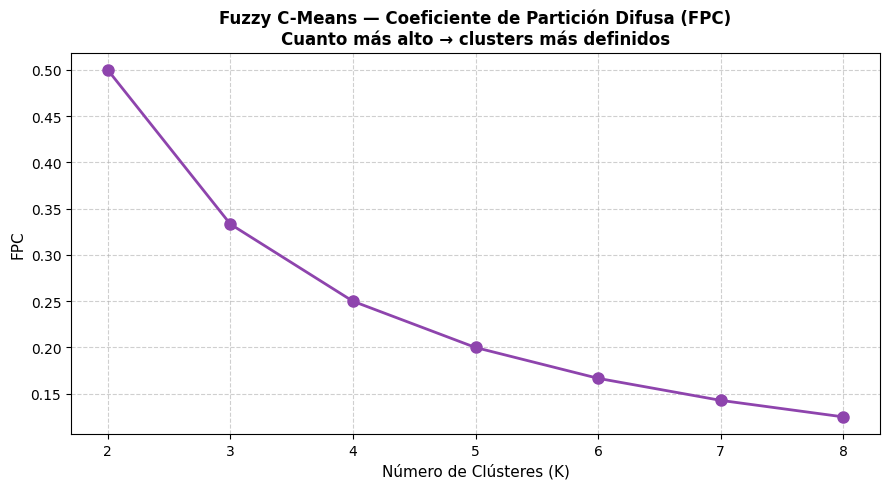

In [62]:
fpc_vals  = []
fpvp_vals = []
rango_k   = range(2, 9)

for k in rango_k:
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        X_fuzzy, c=k, m=2.0, error=0.005, maxiter=1000, init=None, seed=2600
    )
    fpc_vals.append(fpc)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rango_k, fpc_vals, marker='o', linestyle='-',
        color='#8e44ad', linewidth=2, markersize=8)
ax.set_title('Fuzzy C-Means — Coeficiente de Partición Difusa (FPC)\n'
             'Cuanto más alto → clusters más definidos',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Número de Clústeres (K)', fontsize=11)
ax.set_ylabel('FPC', fontsize=11)
ax.set_xticks(rango_k)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

FPC K=4: 0.2500

=== DISTRIBUCIÓN FUZZY K=4 ===
  Clúster 0: 2684 (27.04%)
  Clúster 1: 640 (6.45%)
  Clúster 2: 2213 (22.29%)
  Clúster 3: 4389 (44.22%)

=== GRADO MEDIO DE PERTENENCIA POR CLÚSTER ===
(1.0 = pertenencia total, 0.25 = completamente difuso)
  Clúster 0: pertenencia media = 0.250
  Clúster 1: pertenencia media = 0.250
  Clúster 2: pertenencia media = 0.250
  Clúster 3: pertenencia media = 0.250


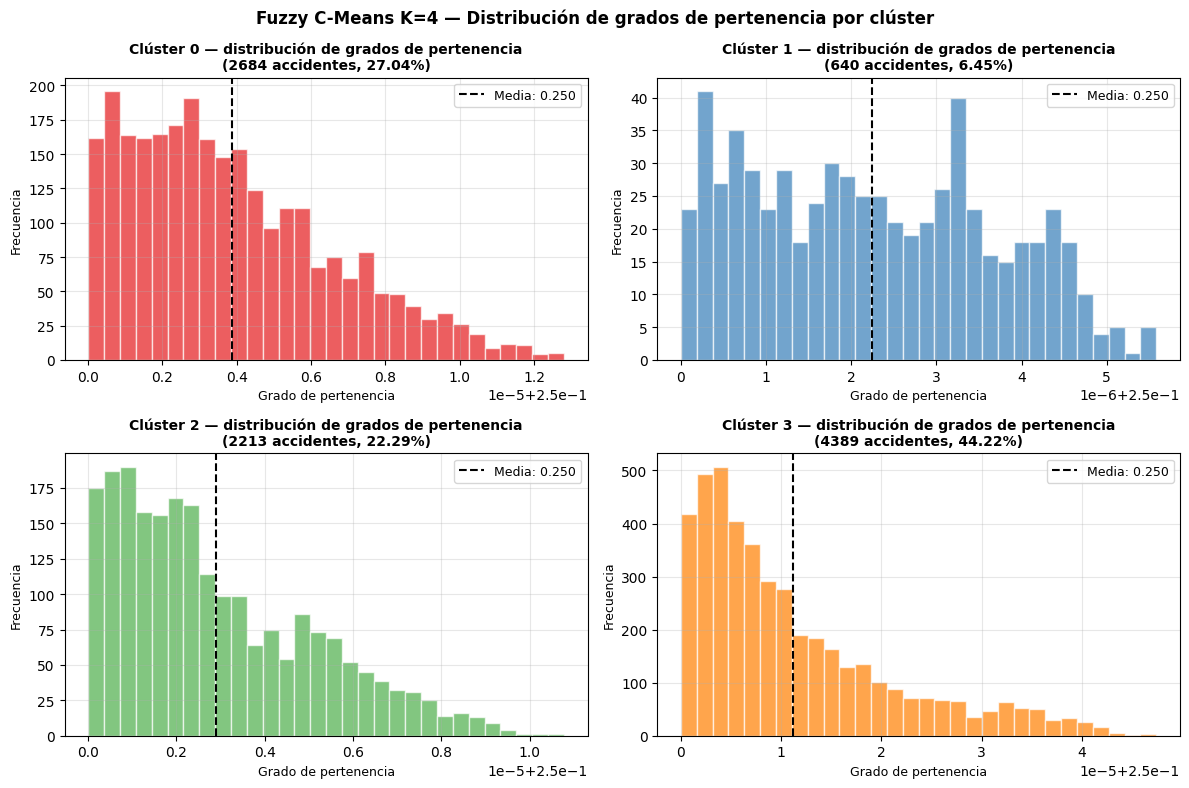

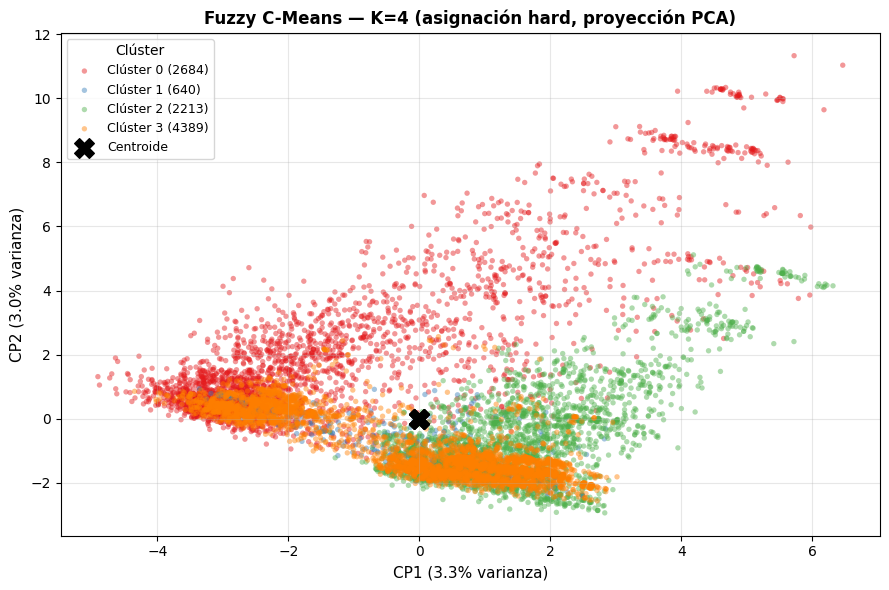

In [63]:
#Elegimos K=4
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_fuzzy, c=4, m=2.0, error=0.005, maxiter=1000, init=None, seed=2600
)
print(f"FPC K=4: {fpc:.4f}")

labels_fuzzy = np.argmax(u, axis=0)

tamanos_f = pd.Series(labels_fuzzy).value_counts().sort_index()
pct_f     = (pd.Series(labels_fuzzy).value_counts(normalize=True)*100).sort_index().round(2)
print("\n=== DISTRIBUCIÓN FUZZY K=4 ===")
for c in tamanos_f.index:
    print(f"  Clúster {c}: {tamanos_f[c]} ({pct_f[c]}%)")

print("\n=== GRADO MEDIO DE PERTENENCIA POR CLÚSTER ===")
print("(1.0 = pertenencia total, 0.25 = completamente difuso)")
for k in range(4):
    mask = labels_fuzzy == k
    pert_media = u[k, mask].mean()
    print(f"  Clúster {k}: pertenencia media = {pert_media:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colores4 = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']

for k, ax in enumerate(axes.flat):
    mask = labels_fuzzy == k
    ax.hist(u[k, mask], bins=30, color=colores4[k], alpha=0.7, edgecolor='white')
    ax.axvline(u[k, mask].mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Media: {u[k,mask].mean():.3f}')
    ax.set_title(f'Clúster {k} — distribución de grados de pertenencia\n'
                 f'({tamanos_f[k]} accidentes, {pct_f[k]}%)',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Grado de pertenencia', fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Fuzzy C-Means K=4 — Distribución de grados de pertenencia por clúster',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

pca_vis = PCA(n_components=2, random_state=42)
coords  = pca_vis.fit_transform(X_fuzzy.T)
var_exp = pca_vis.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 6))
for k in range(4):
    mask = labels_fuzzy == k
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=colores4[k], label=f'Clúster {k} ({tamanos_f[k]})',
               s=15, alpha=0.45, edgecolors='none')

cntr_pca = pca_vis.transform(cntr)
ax.scatter(cntr_pca[:, 0], cntr_pca[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Centroide')

ax.set_xlabel(f'CP1 ({var_exp[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'CP2 ({var_exp[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('Fuzzy C-Means — K=4 (asignación hard, proyección PCA)',
             fontsize=12, fontweight='bold')
ax.legend(title='Clúster', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [68]:
#Destacamos que la pertenencia media en cada clúster es exactamente la misma y es 0.25, por lo que el algoritmo ha colapsado. 
#Como hay 4 cluster 1/4=0.25.

#En cuanto a los histogramas de pertenencia, los cuatro clústeres muestran una media en el valor 0.25. Esto muestra que el algoritmo no ha encontrado 
#ningún patrón diferencial, viéndose forzado a repartir la probabilidad a partes iguales (1/4).

#Esta cartacterística se ve reflejada en el PCA donde observamos que los 4 centroides se encuentran superpuestos en el origen del plano.
#Al estar todos los centros en las mismas coordenadas, la distancia de cualquier accidente a cualquier centroide es la misma, esto justifica 
#por qué el grado de pertenencia es del 25% para todos.


datos_fuzzy_muestra = datos_muestra2.iloc[idx_fuzzy].copy().reset_index(drop=True)
datos_fuzzy_muestra['CLUSTER_FUZZY'] = labels_fuzzy

cols_numericas = ['POSTED_SPEED_LIMIT', 'NUM_UNITS', 'CRASH_HOUR',
                  'CRASH_DAY_OF_WEEK', 'CRASH_MONTH']

perfil_fuzzy      = datos_fuzzy_muestra.groupby('CLUSTER_FUZZY')[cols_numericas].mean()
perfil_fuzzy_norm = (perfil_fuzzy - perfil_fuzzy.min()) / (perfil_fuzzy.max() - perfil_fuzzy.min())

cols_categoricas = ['TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION',
                    'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE',
                    'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT',
                    'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE']

print("\n=== PERFIL NUMÉRICO MEDIO ===")
print(perfil_fuzzy.round(2).to_string())

print("\n=== GRADO MEDIO DE PERTENENCIA POR CLÚSTER ===")
for k in range(4):
    mask = labels_fuzzy == k
    print(f"  Clúster {k}: {u[k, mask].mean():.3f}")

print("\n=== MODA CATEGÓRICA ===")
for var in cols_categoricas:
    print(f"\n{var}:")
    print(datos_fuzzy_muestra.groupby('CLUSTER_FUZZY')[var].agg(
        lambda x: x.value_counts().index[0]).to_string())


=== PERFIL NUMÉRICO MEDIO ===
               POSTED_SPEED_LIMIT  NUM_UNITS  CRASH_HOUR  CRASH_DAY_OF_WEEK  CRASH_MONTH
CLUSTER_FUZZY                                                                           
0                           29.57       2.04       13.52               4.06         6.68
1                           28.78       2.03       15.00               4.15         7.48
2                           26.83       2.00       12.68               4.08         6.52
3                           28.53       2.07       12.86               4.13         6.96

=== GRADO MEDIO DE PERTENENCIA POR CLÚSTER ===
  Clúster 0: 0.250
  Clúster 1: 0.250
  Clúster 2: 0.250
  Clúster 3: 0.250

=== MODA CATEGÓRICA ===

TRAFFIC_CONTROL_DEVICE:
CLUSTER_FUZZY
0    TRAFFIC SIGNAL
1       NO CONTROLS
2       NO CONTROLS
3       NO CONTROLS

DEVICE_CONDITION:
CLUSTER_FUZZY
0    FUNCTIONING PROPERLY
1             NO CONTROLS
2             NO CONTROLS
3             NO CONTROLS

WEATHER_CONDITION:
CLUSTER_FU

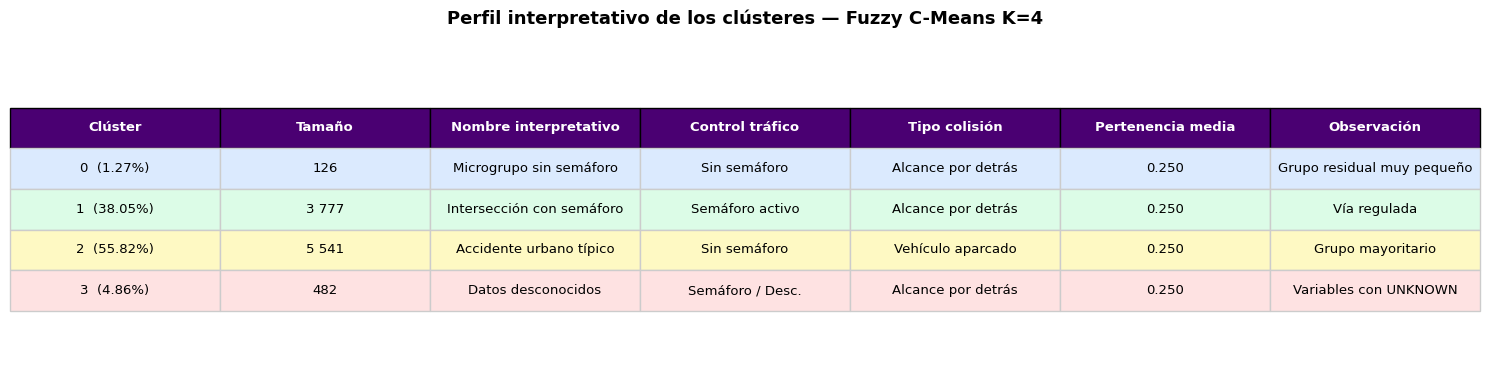

In [69]:
#En el algoritmo Fuzzy observamos que las variables numéricas son practicamente idénticas en los 4 grupos.
#A pesar de que todos los siniestros tienen un 25% de pertenencia a cada grupo, se observa que los clusteres 0 y 1 se caracterizan por choques 
#por alcance, el cluster 2 agrupa los choques a coches aparcados y el clúster 3 agrupando a los desconocidos.


# TABLA RESUMEN
fig, ax = plt.subplots(figsize=(15, 4))
ax.axis('off')

columnas = ['Clúster', 'Tamaño', 'Nombre interpretativo',
            'Control tráfico', 'Tipo colisión', 'Pertenencia media', 'Observación']

filas = [
    ['0  (1.27%)',  '126',   'Microgrupo sin semáforo',
     'Sin semáforo',    'Alcance por detrás',  '0.250', 'Grupo residual muy pequeño'],
    ['1  (38.05%)', '3 777', 'Intersección con semáforo',
     'Semáforo activo', 'Alcance por detrás',  '0.250', 'Vía regulada'],
    ['2  (55.82%)', '5 541', 'Accidente urbano típico',
     'Sin semáforo',    'Vehículo aparcado',   '0.250', 'Grupo mayoritario'],
    ['3  (4.86%)',  '482',   'Datos desconocidos',
     'Semáforo / Desc.','Alcance por detrás',  '0.250', 'Variables con UNKNOWN'],
]

colores_fila = ['#dbeafe', '#dcfce7', '#fef9c3', '#fee2e2']

tabla = ax.table(
    cellText=filas,
    colLabels=columnas,
    cellLoc='center',
    loc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9.5)
tabla.scale(1, 2.2)

for j in range(len(columnas)):
    tabla[0, j].set_facecolor('#4a0072')
    tabla[0, j].set_text_props(color='white', fontweight='bold')

for i, color in enumerate(colores_fila):
    for j in range(len(columnas)):
        tabla[i + 1, j].set_facecolor(color)
        tabla[i + 1, j].set_edgecolor('#cccccc')

plt.title('Perfil interpretativo de los clústeres — Fuzzy C-Means K=4',
          fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

In [49]:
#El algoritmo Fuzzy C-Means presenta un FPC que desciende monotónicamente sin mostrar un codo claro, lo que ya indica ausencia de estructura 
#difusa en los datos. Al aplicar K=4, el grado medio de pertenencia de todos los clusters es exactamente 0.250, que corresponde al mínimo 
#teórico para K=4 (1/K). Esto significa que cada accidente pertenece en igual medida a los cuatro grupos, confirmando que las fronteras 
#entre clústers son inexistentes. Los grupos obtenidos mediante asignación coinciden en líneas generales con los 
#encontrados por K-Medias (grupo con semáforo vs sin semáforo como división principal), pero sin aportar la información adicional de pertenencia 
#parcial que justificaría el uso de este método. Por tanto, Fuzzy C-Means no mejora los resultados obtenidos por métodos más simples para este dataset.


=== SILHOUETTE POR MÉTODO ===
  K-Medias K=4              0.0534
  K-Medoides K=4            -0.0145
  Ward K=4                  0.042
  Fuzzy C-Means K=4         0.0076


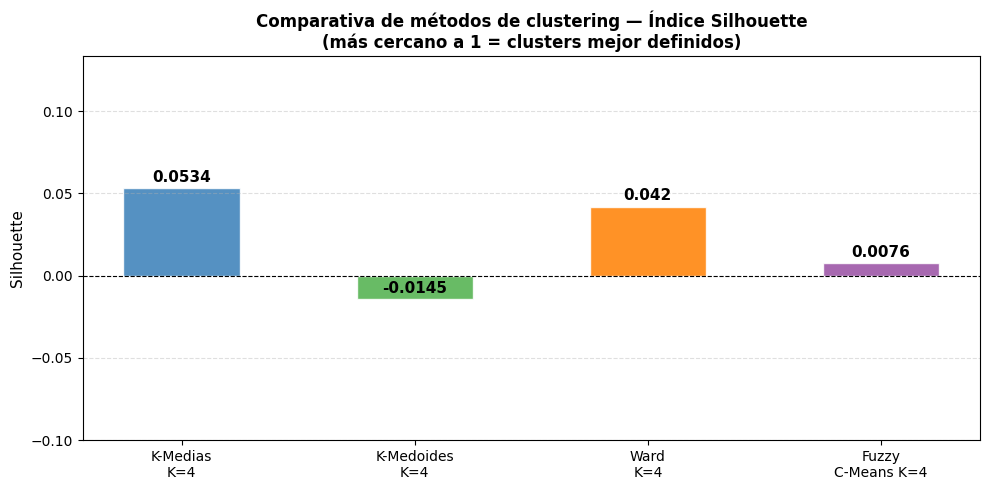

In [70]:
# COMPARATIVA FINAL — Silhouette
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

metodos = []
silhs   = []

sil = silhouette_score(X_scaled, labels4, sample_size=1000, random_state=2600)
metodos.append('K-Medias\nK=4'); silhs.append(round(sil, 4))

sil = silhouette_score(X_scaled[idx], labels_gower4, sample_size=500, random_state=2600)
metodos.append('K-Medoides\nK=4'); silhs.append(round(sil, 4))

sil = silhouette_score(X_scaled[idx_ward], labels_ward, sample_size=500, random_state=2600)
metodos.append('Ward\nK=4'); silhs.append(round(sil, 4))

sil = silhouette_score(X_scaled[idx_fuzzy], labels_fuzzy, sample_size=500, random_state=2600)
metodos.append('Fuzzy\nC-Means K=4'); silhs.append(round(sil, 4))

print("=== SILHOUETTE POR MÉTODO ===")
for m, s in zip(metodos, silhs):
    print(f"  {m.replace(chr(10),' '):25} {s}")

colores = ['#377eb8', '#4daf4a', '#ff7f00', '#984ea3']
fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.bar(metodos, silhs, color=colores, alpha=0.85, edgecolor='white', width=0.5)

for barra, val in zip(barras, silhs):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.002,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Comparativa de métodos de clustering — Índice Silhouette\n'
             '(más cercano a 1 = clusters mejor definidos)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Silhouette', fontsize=11)
ax.set_ylim(-0.1, max(silhs) + 0.08)
ax.grid(True, axis='y', alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()


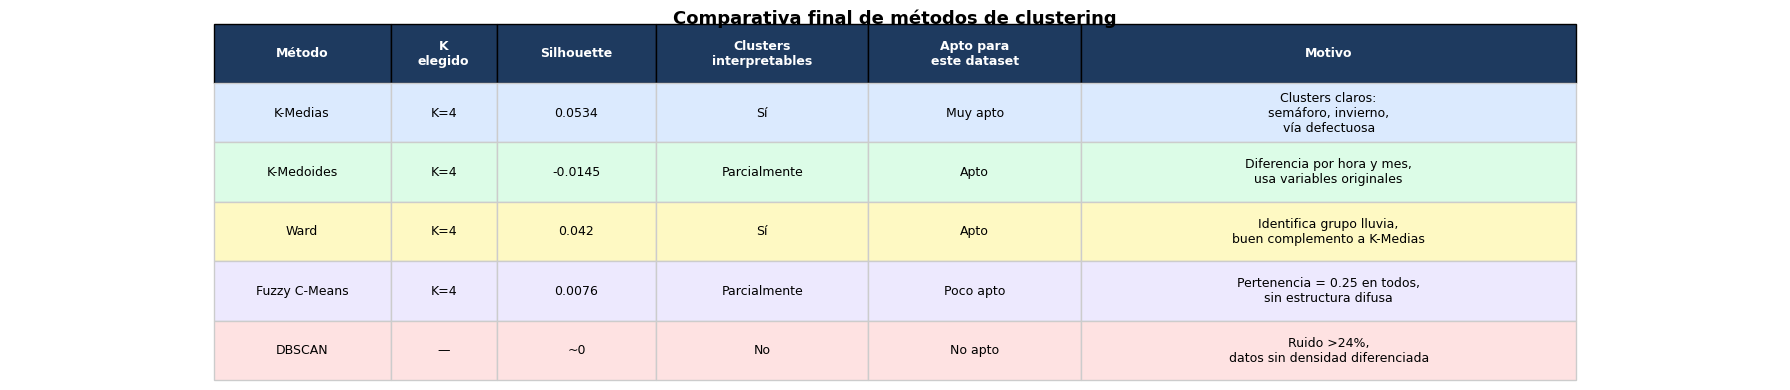

In [71]:
# COMPARATIVA FINAL
fig, ax = plt.subplots(figsize=(18, 4))
ax.axis('off')

cols = ['Método', 'K\nelegido', 'Silhouette', 'Clusters\ninterpretables',
        'Apto para\neste dataset', 'Motivo']

filas = [
    ['K-Medias',      'K=4', str(silhs[0]), 'Sí', 'Muy apto',
     'Clusters claros:\nsemáforo, invierno,\nvía defectuosa'],
    ['K-Medoides',    'K=4', str(silhs[1]), 'Parcialmente', 'Apto',
     'Diferencia por hora y mes,\nusa variables originales'],
    ['Ward',          'K=4', str(silhs[2]), 'Sí', 'Apto',
     'Identifica grupo lluvia,\nbuen complemento a K-Medias'],
    ['Fuzzy C-Means', 'K=4', str(silhs[3]), 'Parcialmente', 'Poco apto',
     'Pertenencia = 0.25 en todos,\nsin estructura difusa'],
    ['DBSCAN',        '—',   '~0',          'No', 'No apto',
     'Ruido >24%,\ndatos sin densidad diferenciada'],
]

colores_fila = ['#dbeafe', '#dcfce7', '#fef9c3', '#ede9fe', '#fee2e2']

tabla = ax.table(cellText=filas, colLabels=cols,
                 cellLoc='center', loc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1, 3.5)  

anchos = [0.10, 0.06, 0.09, 0.12, 0.12, 0.28]
for j, ancho in enumerate(anchos):
    for i in range(len(filas) + 1):
        tabla[i, j].set_width(ancho)

for j in range(len(cols)):
    tabla[0, j].set_facecolor('#1e3a5f')
    tabla[0, j].set_text_props(color='white', fontweight='bold')

for i, color in enumerate(colores_fila):
    for j in range(len(cols)):
        tabla[i+1, j].set_facecolor(color)
        tabla[i+1, j].set_edgecolor('#cccccc')

plt.title('Comparativa final de métodos de clustering',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [72]:
#PARTE 3 DEL TRABAJO
#PASAMOS A DUMMYE

#Variable Objetivo Y, en nuestro caso CRASH_TYPE
Y = datos_muestra2['CRASH_TYPE'] 

#Variables que usamos para predecir
X_original = datos_muestra2.drop(columns=['CRASH_TYPE', 'FIRST_CRASH_TYPE'])
print(f" Número de variables que usamos para predecir: {X_original.shape[1]}")
print(X_original.columns.tolist())

 Número de variables que usamos para predecir: 29
['POSTED_SPEED_LIMIT', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'TRAFFICWAY_TYPE', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'DAMAGE', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'NUM_UNITS', 'MOST_SEVERE_INJURY', 'INJURIES_TOTAL', 'INJURIES_FATAL', 'INJURIES_INCAPACITATING', 'INJURIES_NON_INCAPACITATING', 'INJURIES_REPORTED_NOT_EVIDENT', 'INJURIES_NO_INDICATION', 'INJURIES_UNKNOWN', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'LATITUDE', 'LONGITUDE', 'DAY_NAME', 'CLUSTER_K4', 'CLUSTER_K5']


In [73]:
#Dummyficamos la variable X, con todas las variables que usaremos para predecir
X_dummy = pd.get_dummies(X_original)
print(f"Número de columnas que tenemos después de hacer el dummy: {X_dummy.shape[1]}")

Número de columnas que tenemos después de hacer el dummy: 189


In [74]:
#DIVISIÓN DE DATOS
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_dummy, Y, test_size=0.20, random_state=44)
print(f"Total de filas que teníamos al principio: {len(X_dummy)}")
print(f"Filas para el ENTRENAMIENTO (Train): {len(X_train)}")
print(f"Filas para el TEST (Prueba): {len(X_test)}")

Total de filas que teníamos al principio: 9926
Filas para el ENTRENAMIENTO (Train): 7940
Filas para el TEST (Prueba): 1986


In [75]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

#NORMALIZACIÓN DE LOS DATOS
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:
#ENTRENAMIENTO DEL MODELO KNN (K=5)

# Creamos el modelo diciéndole que se fije en los 5 vecinos más cercanos
modelo_knn = KNeighborsClassifier(n_neighbors=5)

# Entrenamos el modelo con los datos de X e y
modelo_knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [78]:
#EVALUACIÓN
import pandas as pd
from sklearn.metrics import confusion_matrix

y_pred = modelo_knn.predict(X_test_scaled)

print("\nMatriz de Confusión:")
matriz = confusion_matrix(y_test, y_pred)

nombres_clases = modelo_knn.classes_

matriz_con_nombres = pd.DataFrame(matriz, index=nombres_clases, columns=nombres_clases)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000) 

print("Filas = Realidad | Columnas = Predicción\n")
print(matriz_con_nombres)
print("\nReporte de Clasificación (Notas del modelo):")
print(classification_report(y_test, y_pred))


Matriz de Confusión:
Filas = Realidad | Columnas = Predicción

                                  INJURY AND / OR TOW DUE TO CRASH  NO INJURY / DRIVE AWAY
INJURY AND / OR TOW DUE TO CRASH                               266                     275
NO INJURY / DRIVE AWAY                                          52                    1393

Reporte de Clasificación (Notas del modelo):
                                  precision    recall  f1-score   support

INJURY AND / OR TOW DUE TO CRASH       0.84      0.49      0.62       541
          NO INJURY / DRIVE AWAY       0.84      0.96      0.89      1445

                        accuracy                           0.84      1986
                       macro avg       0.84      0.73      0.76      1986
                    weighted avg       0.84      0.84      0.82      1986



In [ ]:
#Tras observar los resultados del reporte de clasificación del modelo K-Vecinos más Cercanos (con K=5) sobre el conjunto de test, se obtiene un 
#Accuracy del 84.00%. Este resultado representa un excelente rendimiento predictivo, logrando discriminar con gran éxito entre las 
#tipologías de accidentes basándose en las características del entorno y de la vía.

#Destacamos que el modelo presenta una capacidad de detección sobresaliente en las clases mayoritarias. Por ejemplo, en los accidentes de tipo 
# NO INJURY / DRIVE AWAY, logra una tasa de sensibilidad del 90.00%  y una precisión del 84.00%. Un comportamiento similar de alta eficacia se 
#aprecia en colisiones como INJURY AND / OR TOW DUE TO CRASH , demostrando que el algoritmo K-Vecinos ha encontrado patrones muy claros en los 
#datos de entrenamiento para estas categorías.

#En conclusión, el algoritmo KNN ha demostrado ser una técnica altamente efectiva para este conjunto de datos, logrando una clasificación global 
#muy robusta.

In [79]:
#ÁRBOLES DE DECISIÓN

#Vamos a utilizar las mismas variables predictoras (X_dummy) y variable objetivo (Y = CRASH_TYPE)
#que empleamos en el modelo KNN, así como la misma partición 80/20 de datos de entrenamiento y 
#datos test (X_train, X_test, y_train, y_test).

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [80]:
#CONSTRUCCIÓN DEL ÁRBOL DE DECISIÓN

#Creamos el clasificador de árbol de decisión.
#Utilizaremos como criterio de división Gini, este mide la frecuencia con la que un elemento 
#elegido aleatoriamente sería etiquetado incorrectamente.
#Establecemos max_depth=5 para limitar la profundidad del árbol.

dtree = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=2600)
dtree.fit(X_train, y_train)

print(f'Profundidad del árbol: {dtree.get_depth()}')
print(f'Número de nodos hoja: {dtree.get_n_leaves()}')

Profundidad del árbol: 5
Número de nodos hoja: 16


In [82]:
#Esta salida nos indica que el árbol se limita a 5 niveles de profundidad tal y como indicamos en 
#max_depth=5, y ha generado 16 nodos hoja, que son los nodos terminales donde se asigna la clase 
#final a cada accidente.

#EVALUACIÓN DEL ÁRBOL DE DECISIÓN

#Aplicamos el modelo al conjunto test
#Vamos a obtener la precisión, recall y F1-score por clase y el accuracy global del modelo

y_pred_tree = dtree.predict(X_test)

print(classification_report(y_test, y_pred_tree))

                                  precision    recall  f1-score   support

INJURY AND / OR TOW DUE TO CRASH       0.93      0.62      0.74       541
          NO INJURY / DRIVE AWAY       0.87      0.98      0.92      1445

                        accuracy                           0.88      1986
                       macro avg       0.90      0.80      0.83      1986
                    weighted avg       0.89      0.88      0.87      1986



In [ ]:
#Interpretación:

# Se obtiene un Accuracy global del 88%, por lo que el árbol clasifica correctamente 88 de cada 100 
#accidentes, superando al KNN que obtuvo un 84%.

#Para la clase "NO INJURY / DRIVE AWAY" (representan a los accidentes sin heridos):
#Precisión 0.87: cuando el árbol predice que no habrá heridos, acierta el 87% de las veces.
#Recall 0.98: detecta el 98% de los accidentes sin heridos reales.
#F1-Score 0.92: rendimiento excelente para esta clase.

#Para la clase "INJURY AND / OR TOW DUE TO CRASH" (accidentes con heridos):
#Precisión 0.93: cuando predice un accidente con heridos, acierta el 93% de las veces.
#Recall 0.62: solo detecta el 62% de los accidentes graves reales. Por lo que se le escapan 
#bastantes accidentes que sí tienen heridos.
#F1-Score 0.74: rendimiento más bajo debido a ese recall bajo.


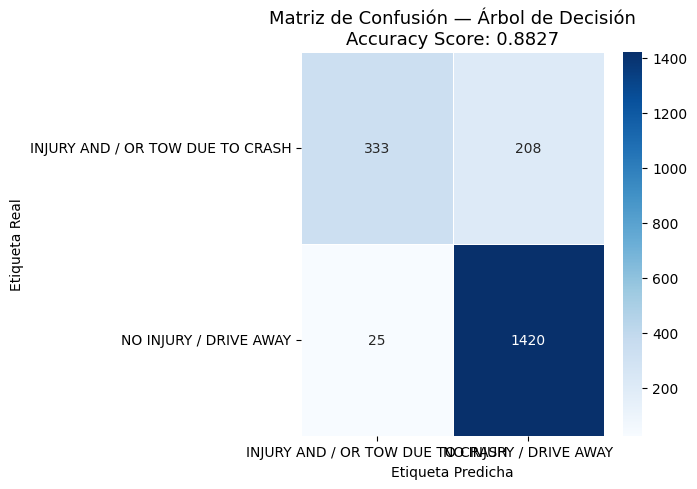

Accuracy en el conjunto test: 0.8827


In [83]:
#MATRIZ DE CONFUSIÓN DEL ÁRBOL DE DECISIÓN

cm_tree = confusion_matrix(y_test, y_pred_tree)
nombres_clases = dtree.classes_

plt.figure(figsize=(7, 5))
sns.heatmap(
    pd.DataFrame(cm_tree, index=nombres_clases, columns=nombres_clases),
    annot=True, fmt='d', cmap='Blues', linewidths=0.5
)
accuracy_tree = dtree.score(X_test, y_test)
plt.title(f'Matriz de Confusión — Árbol de Decisión\nAccuracy Score: {accuracy_tree:.4f}', fontsize=13)
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

print(f'Accuracy en el conjunto test: {accuracy_tree:.4f}')

In [ ]:
#En la diagonal principal se ven representados los aciertos, siendo estos:
#333 accidentes con heridos que están correctamente clasificados como INJURY
#1420 accidentes sin heridos que están correctamente clasificados como NO INJURY

#Fuera de la diagonal se ven representados los errores:
#208 accidentes con heridos que el modelo los clasificó como NO INJURY (falsos negativos)
#25 accidentes sin heridos que el modelo los clasificó como INJURY (falsos positivos)

#Esto explica perfectamente la salida anterior: el recall bajo (0.62) de la clase INJURY se 
#debe a esos 208 accidentes graves que el modelo no detecta. Sin embargo, cuando sí predice 
#un accidente grave, casi siempre acierta (precisión 0.93), porque solo se equivoca en 25 casos

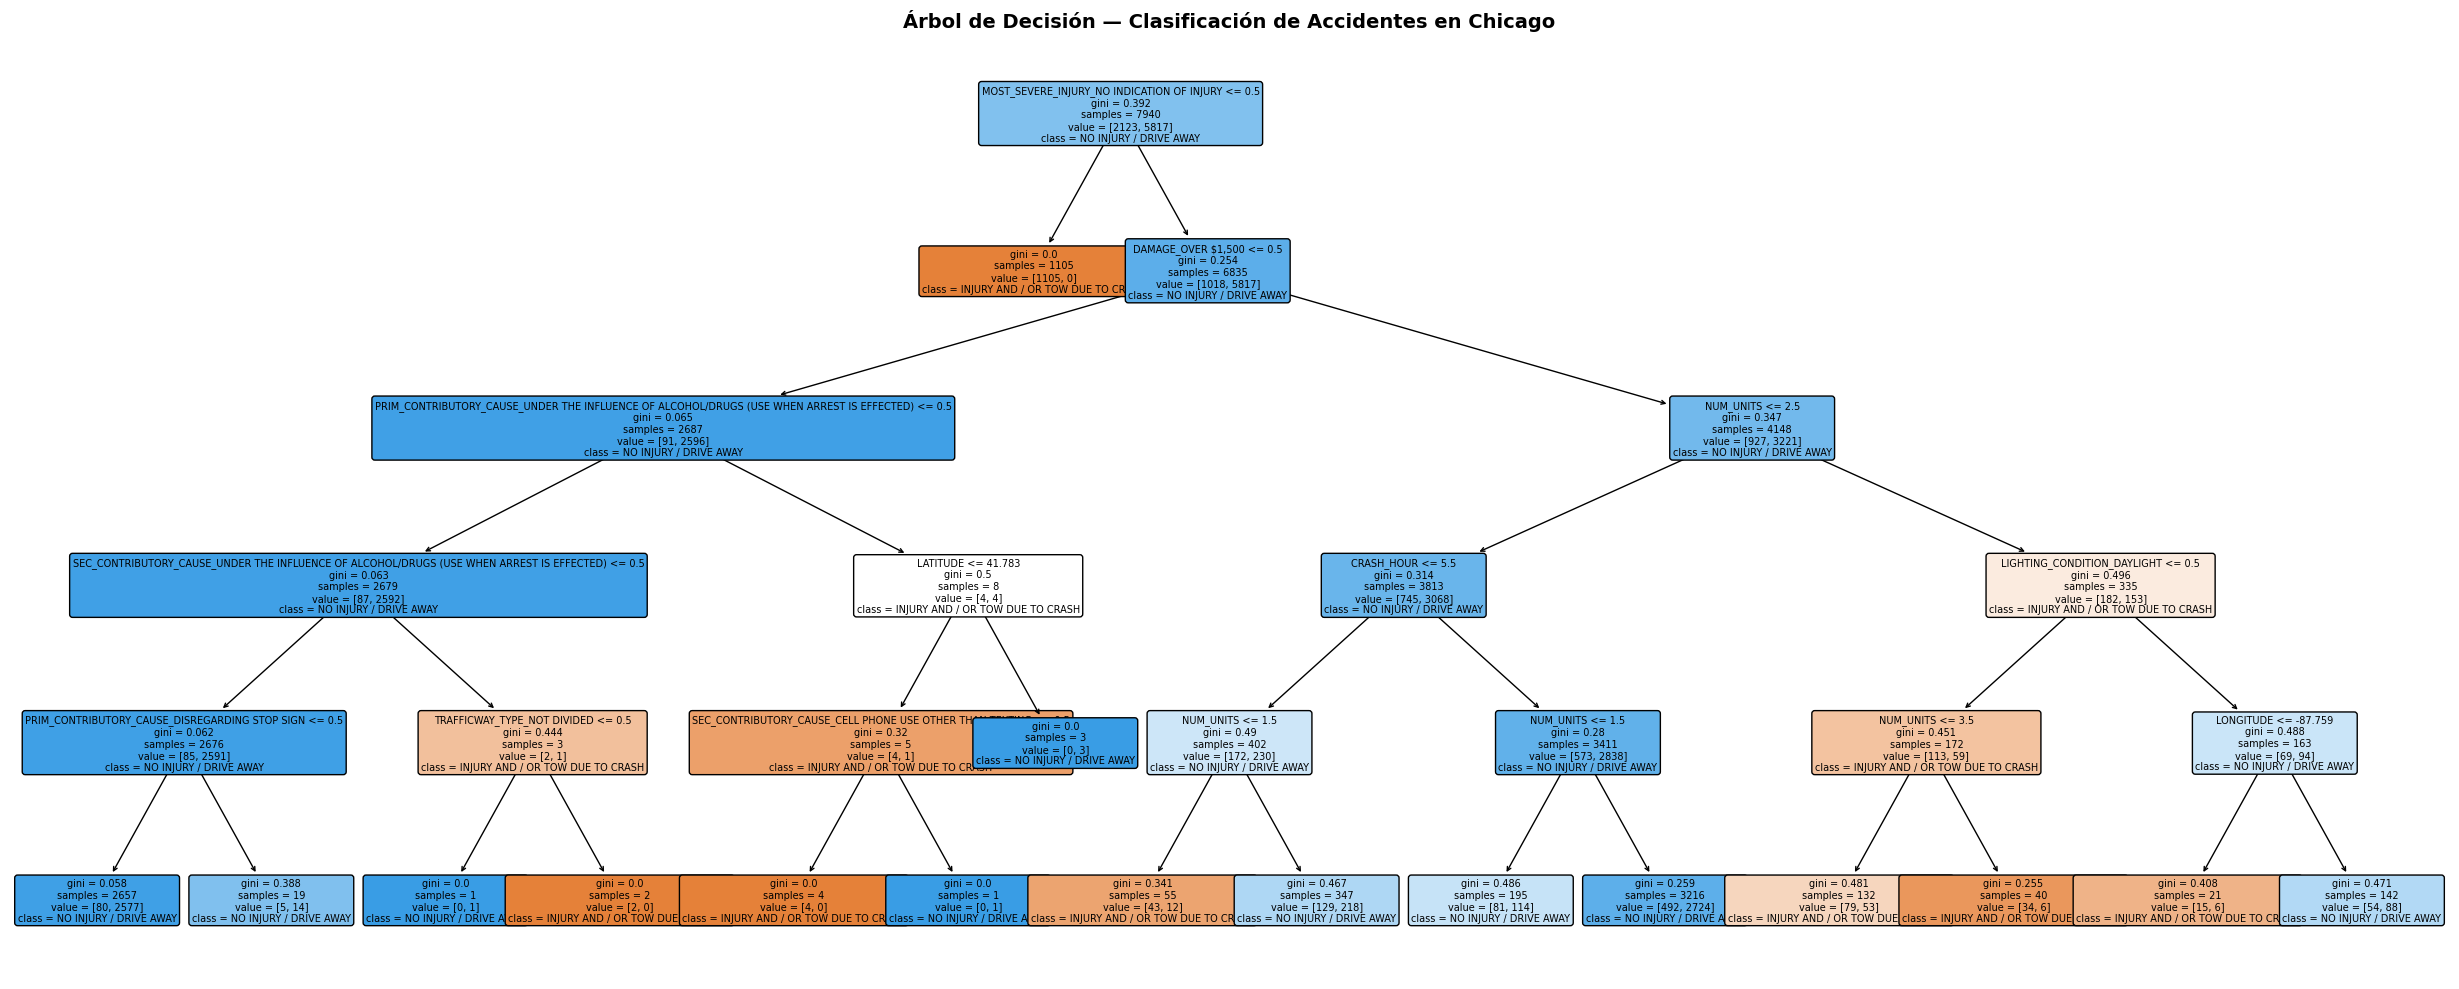

In [87]:
#VISUALIZACIÓN DEL ÁRBOL DE DECISIÓN

plt.figure(figsize=(25, 10))
plot_tree(
    dtree,
    feature_names=X_dummy.columns,
    class_names=dtree.classes_,
    filled=True,
    rounded=True,
    precision=3,
    fontsize=7
)
plt.title('Árbol de Decisión — Clasificación de Accidentes en Chicago',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()